# QF 627 Programming and Computational Finance
## Mock Assessment Paper 2: Comprehensive Practice Exam

***

> Good day, Team 👋

> This is your **second mock assessment** designed to provide additional practice and reinforce your understanding of the key topics covered in this course.

> This assessment covers: **data wrangling**, **rule-based algorithmic trading strategies**, **supervised machine learning**, and **unsupervised learning techniques** including PCA, t-SNE, K-Means clustering, and hierarchical clustering.

> The questions in this paper are different from Mock Paper 1, giving you fresh scenarios to test your knowledge and build exam confidence.

***

> **Time allocation**: You have **3 hours** to complete this assessment.

> **Format**: This is an open-book assessment. You may refer to course materials, notes, and documentation.

> **Submission**: Save your completed notebook with your last name (e.g., `YourLastName_MockExam2.ipynb`)

> **Strategy**: If you cannot complete a question, move forward and return later. Maximize your time efficiency.

***

> Best of luck with your preparation! 🍀

***

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [2]:
# Our standardized printing options

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

np.set_printoptions(precision = 3)

pd.set_option("display.float_format", lambda x: "%.3f" % x)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## List of Questions

    IMPORTANT NOTE: 

### <font color = purple> <center> Data wrangling is a critical component of this assessment. 

### <font color = purple> <center> Ensure your data is properly prepared to obtain accurate results.

### <font color = purple> <center> All functions must be written within this notebook script.

***
# SECTION A: Data Wrangling & Rule-Based Trading Strategies
***

##  <font color = blue> 👉 Question 1. </font> Data Collection and Preparation (15 points)

### Download historical price data for the following securities from Yahoo Finance for the period **January 1, 2016 to December 31, 2021**:

- **ETF_A**: SPY (S&P 500 ETF)
- **ETF_B**: QQQ (NASDAQ-100 ETF)
- **Stock_A**: JPM (JPMorgan Chase)
- **Stock_B**: GS (Goldman Sachs)

### Tasks:

a) Download the data using `yfinance` with the specified date range

b) For each security, check and report:
   - Number of missing values in the `Adj Close` column
   - Date of first and last observation
   - Total number of trading days

c) Handle missing values using forward-fill method, then verify no missing values remain

d) Create a combined DataFrame containing only the `Adj Close` prices of all four securities

e) Calculate and display the correlation matrix of the four securities

f) Which pair of securities shows the highest correlation?

In [3]:
# import yfinance as yf
# import pandas as pd
# from datetime import datetime

# # Define the two groups of tickers
# group1_tickers = ['SPY', 'QQQ', 'JPM', 'GS']
# group2_tickers = ['XLF', 'XLE', 'XLK', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLRE']

# # Define the date range
# start_date = '2015-01-01'
# end_date = datetime.today().strftime('%Y-%m-%d')

# print(f"Downloading data from {start_date} to {end_date}...")

# # Download Group 1: ETF_A, ETF_B, Stock_A, Stock_B
# print("\nDownloading Group 1 (SPY, QQQ, JPM, GS)...")
# group1_data = yf.download(group1_tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)
# group1_data.to_csv('group1_etf_stocks.csv')
# print("Group 1 saved to: group1_etf_stocks.csv")

# # Download Group 2: Sector ETFs
# print("\nDownloading Group 2 (Sector ETFs)...")
# group2_data = yf.download(group2_tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)
# group2_data.to_csv('group2_sector_etfs.csv')
# print("Group 2 saved to: group2_sector_etfs.csv")

# print("\n✓ Download complete!")
# print(f"Group 1 shape: {group1_data.shape}")
# print(f"Group 2 shape: {group2_data.shape}")


### Below are the lines of code that lead to an answer:

### IMPORT & DOWNLOAD

In [8]:
# TODO csv download
def download_csv_data(file_path):
    """
    Download stock data from a CSV file
    """
    stock_data = pd.read_csv(file_path, 
                             index_col=0, 
                             parse_dates=True)
    return stock_data

## Read multi-index
stock_data = pd.read_csv('group1_etf_stocks.csv', 
                        index_col=0, 
                        parse_dates=True,
                        header=[0,1]
                        )

In [9]:
## Slice Multi-index to get 'Adj Close' prices only
# stock_data = stock_data.xs('Adj Close', level=1, axis=1)
## Slice Multi-index to get 'Adj Close' prices only
stock_data = stock_data.xs('Adj Close', level=1, axis=1)


In [10]:
stock_data

Ticker,JPM,QQQ,GS,SPY
Date,,,,
2015-01-02,46.721,94.907,157.149,171.094
2015-01-05,45.270,93.514,152.242,168.004
2015-01-06,44.097,92.261,149.163,166.421
2015-01-07,44.164,93.450,151.386,168.495
2015-01-08,45.151,95.238,153.803,171.485
...,...,...,...,...
2025-11-03,309.350,632.080,785.520,683.340
2025-11-04,309.250,619.250,790.830,675.240
2025-11-05,311.680,623.280,793.090,677.580


In [12]:
# stock_data = stock_data.droplevel('Price',axis=1)

In [14]:
stock_data = stock_data.loc['2016-01-01': '2022-01-01']

for ticker in stock_data.columns:
    print(f"For {ticker}:")
    print(f"missing vals: {stock_data[ticker].isnull().sum()}")
    print(f"start: {stock_data[ticker].index[0]}, end: {stock_data[ticker].index[-1]}")
    print(f"Total trading days: {stock_data[ticker].shape[0]}")


For JPM:
missing vals: 0
start: 2016-01-04 00:00:00, end: 2021-12-31 00:00:00
Total trading days: 1511
For QQQ:
missing vals: 0
start: 2016-01-04 00:00:00, end: 2021-12-31 00:00:00
Total trading days: 1511
For GS:
missing vals: 0
start: 2016-01-04 00:00:00, end: 2021-12-31 00:00:00
Total trading days: 1511
For SPY:
missing vals: 0
start: 2016-01-04 00:00:00, end: 2021-12-31 00:00:00
Total trading days: 1511


In [15]:
# Create combined DataFrame with Adj Close prices
stock_data.corr()

Ticker,JPM,QQQ,GS,SPY
Ticker,,,,
JPM,1.000,0.899,0.892,0.947
QQQ,0.899,1.000,0.839,0.990
GS,0.892,0.839,1.000,0.873
SPY,0.947,0.990,0.873,1.000


In [16]:
stock_data.pct_change().corr()

Ticker,JPM,QQQ,GS,SPY
Ticker,,,,
JPM,1.000,0.547,0.851,0.754
QQQ,0.547,1.000,0.591,0.918
GS,0.851,0.591,1.000,0.750
SPY,0.754,0.918,0.750,1.000


In [17]:
# Calculate correlation matrix

### <font color = red> Answer 1 </font>

    ETF_A (SPY):
    - Missing values: ____________
    - Trading days: ____________
    - First date: ____________
    - Last date: ____________
    
    ETF_B (QQQ):
    - Missing values: ____________
    - Trading days: ____________
    
    Stock_A (JPM):
    - Missing values: ____________
    - Trading days: ____________
    
    Stock_B (GS):
    - Missing values: ____________
    - Trading days: ____________
    
    Highest correlation pair: ____________ and ____________
    Correlation coefficient: ____________

    Highest correlation pair: SPY and QQQ
    Correlation coefficient: 0.918

##  <font color = blue> 👉 Question 2. </font> RSI-Based Mean Reversion Strategy (30 points)

### Implement a mean-reversion trading strategy using the Relative Strength Index (RSI) for **ETF_A (SPY)**.

### Strategy Rules:

**RSI Calculation**:
- Period: 14 days
- RSI = 100 - (100 / (1 + RS))
- RS = Average Gain / Average Loss

**Trading Signals**:
- **Buy Signal (Signal = 1)**: RSI < 30 (oversold)
- **Sell Signal (Signal = 0)**: RSI > 70 (overbought)
- **Hold**: Maintain previous signal if 30 ≤ RSI ≤ 70

### Assumptions:
- Initial capital: **$200,000**
- Trade size: **1,000 shares** when signal is 1
- Use `Adj Close` price
- Position is calculated as: shares × signal (lagged by 1 day)

### Tasks:

a) Calculate the 14-day RSI

b) Generate trading signals based on RSI thresholds

c) Calculate positions and P&L

d) Report total P&L and final portfolio value

e) Calculate the strategy's win rate (percentage of profitable trades)

f) Visualize:
   - Price and RSI in subplots
   - Mark buy/sell signals on the price chart

### Below are the lines of code that lead to an answer:

In [ ]:
def get_rsi(df, period_list=[10, 30, 200]):
    """
    Calculate RSI (Relative Strength Index)
    Parameters:
    df: pandas df of closing price
    period_list: RSI period (default [10, 30, 200])
    Returns:
    pandas df with RSI values
    """
    # Make a copy to avoid SettingWithCopyWarning
    df = df.copy()
    
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi
        
    return df

In [22]:
spy = stock_data[['SPY']]
rsi_list = [14]

spy = get_rsi(spy,rsi_list).dropna()

In [23]:
upper = 70
lower = 30

spy['positions'] =\
(
    np.where(
        spy['rsi_14'] < lower, 1,
            np.where(
                spy['rsi_14'] > upper, 0, np.nan
                    # np.where(
                    #     (spy[spy.columns[0]] < spy[f'sma_{window}']) & 
                    #     (spy[spy.columns[0]] > spy[f'sma_{window}']).shift(1), 0,
                    #         np.where(
                    #             (spy[spy.columns[0]] > spy[f'sma_{window}']) & 
                    #             (spy[spy.columns[0]] < spy[f'sma_{window}']).shift(1), 0, np.nan
                    #         )
                    # )
            )
    )
)
spy['positions'] = spy['positions'].ffill().fillna(0)

In [24]:
def get_returns_log(df, position_shift, shares):
    """
    Log returns, given a list of positions and stock price in first column
    Usage: get_returns_log(aapl, 0)
    """
    df['positions'] = df['positions'].shift(position_shift).fillna(0)      # IMPORTANT
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] = \
    (
        np.log(
            df[df.columns[0]] / 
                df[df.columns[0]].shift(1)
        )
    ).fillna(0)
    df['strategy_returns'] = \
    (
        df['passive_returns'] * df['positions'].fillna(0)
    )
    df['cum_passive_returns'] = \
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] = \
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['pnl'] = (df[df.columns[0]].diff() * df['positions'].shift(1) * shares).fillna(0)
    

    return df

In [25]:
spy = get_returns_log(spy, position_shift=1, shares=1_000)

In [26]:
spy

Ticker,SPY,rsi_14,positions,trade,passive_returns,strategy_returns,cum_passive_returns,cum_strategy_returns,pnl
Date,,,,,,,,,
2016-01-25,159.502,30.312,0.000,0.000,0.000,0.000,1.000,1.000,0.000
2016-01-26,161.678,35.541,0.000,0.000,0.014,0.000,1.014,1.000,0.000
2016-01-27,159.919,33.361,0.000,0.000,-0.011,-0.000,1.003,1.000,-0.000
2016-01-28,160.752,35.382,0.000,0.000,0.005,0.000,1.008,1.000,0.000
2016-01-29,164.670,43.987,0.000,0.000,0.024,0.000,1.032,1.000,0.000
...,...,...,...,...,...,...,...,...,...
2021-12-27,452.783,61.780,0.000,0.000,0.014,0.000,2.839,1.296,0.000
2021-12-28,452.413,61.372,0.000,0.000,-0.001,-0.000,2.836,1.296,-0.000
2021-12-29,452.992,61.797,0.000,0.000,0.001,0.000,2.840,1.296,0.000


In [27]:
# Apply RSI strategy to ETF_A

In [28]:
# Calculate total P&L and metrics

In [29]:
# Calculate win rate

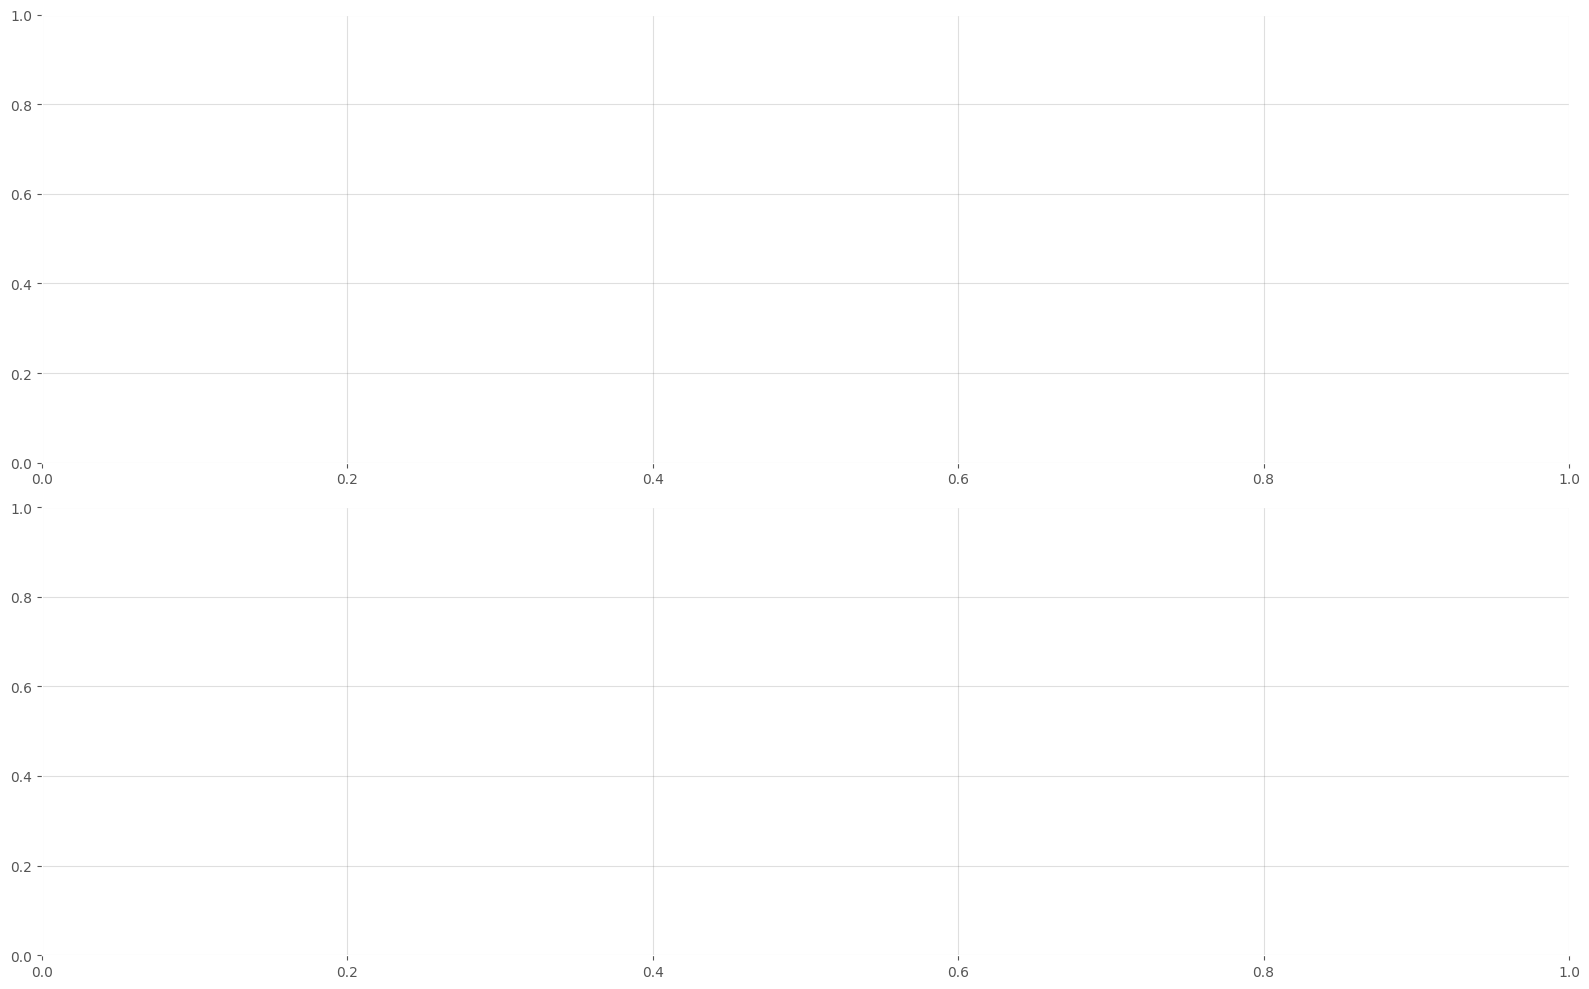

In [30]:
# Visualization
fig, axes = plt.subplots(2, 1, figsize = [16, 10])

# Your visualization code here

plt.tight_layout()
plt.show()

### <font color = red> Answer 2 </font>

    Total P&L: $____________
    
    Initial Capital: $200,000
    Final Portfolio Value: $____________
    
    Total Return: ____________%
    
    Number of buy signals: ____________
    Number of sell signals: ____________
    
    Win Rate: ____________%

In [31]:
spy.pnl.sum()

np.float64(65109.23767089844)

In [32]:
# total PNL and CAGR
initial_capital = 200_000
print(f"    Total P&L for Stock X (AAPL) using RSI Mean-reversion strategy: ${spy.pnl.sum()}")
print(f"    Initial Capital: ${initial_capital:,.0f}")
print(f"    Final portfolio value Return: ${spy.pnl.sum() + initial_capital:,.0f}")
print(f"    Total Return: {spy.pnl.sum() / initial_capital:.2%}")
print(f"    Number of buy signals: {spy['trade'][spy['trade']>0].count()}")
print(f"    Number of sell signals: {spy['trade'][spy['trade']<0].count()}")
print(f"    Win Rate: {(spy['strategy_returns'][spy['strategy_returns']>0].count() / 
                         spy['strategy_returns'][(spy['strategy_returns']>0) | (spy['strategy_returns']<0)].count()):.2%}")


    Total P&L for Stock X (AAPL) using RSI Mean-reversion strategy: $65109.23767089844
    Initial Capital: $200,000
    Final portfolio value Return: $265,109
    Total Return: 32.55%
    Number of buy signals: 5
    Number of sell signals: 5
    Win Rate: 56.98%


In [33]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

spy_melt = spy.reset_index()
# spy_melt = spy_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(spy_melt, aes(x='Date')) +
    geom_line(aes(y='SPY'), color='grey', size=0.7) +
    # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='SPY'), data=spy_melt[spy_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='SPY'), data=spy_melt[spy_melt['trade']<-0.0], color='red', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


display(p)

q =\
(
    ggplot(spy_melt, aes(x='Date')) +
    geom_line(aes(y='rsi_14'), color='grey', size=0.7) +
    # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='rsi_14'), data=spy_melt[spy_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='rsi_14'), data=spy_melt[spy_melt['trade']<-0.0], color='red', size=3) +
    ggtitle("RSI Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


q

##  <font color = blue> 👉 Question 3. </font> Triple Moving Average Crossover Strategy (30 points)

### Implement a momentum strategy using three moving averages for **Stock_A (JPM)**.

### Strategy Rules:

**Moving Averages**:
- Fast MA: 20-day SMA
- Medium MA: 50-day SMA  
- Slow MA: 100-day SMA

**Trading Signals**:
- **Strong Buy (Signal = 2)**: Fast > Medium AND Medium > Slow
- **Buy (Signal = 1)**: Fast > Medium OR Medium > Slow (but not both)
- **Sell (Signal = 0)**: Fast < Medium AND Medium < Slow

### For rolling statistics: `min_periods = 1`, `center = False`

### Assumptions:
- Initial capital: **$150,000**
- Trade size: 
  - **500 shares** when Signal = 2
  - **250 shares** when Signal = 1
  - **0 shares** when Signal = 0
- Position lagged by 1 day

### Tasks:

a) Calculate the three moving averages

b) Generate multi-level trading signals

c) Calculate positions and P&L

d) Report total P&L

e) Calculate maximum consecutive winning days and losing days

f) Visualize the price with all three moving averages and color-coded signal regions

### Below are the lines of code that lead to an answer:

In [34]:
def triple_ma_strategy(df,
                       price_column = "Adj Close",
                       fast = 20,
                       medium = 50,
                       slow = 100):
    """
    Implement triple moving average momentum strategy
    """
    df_strat = df.copy()
    
    # Your code here
    
    return df_strat

In [39]:
# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    df = df.copy()
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

# sma_list = [21, 63, 252]
# df_sma = get_sma(ticker_data[[target]].copy(), sma_list).drop(columns=target)

# sub_df_list.append(df_sma)



In [40]:
# Apply strategy to Stock_A (JPM)
jpm = stock_data[['JPM']]
sma_list = [20, 50, 100]

jpm = get_sma(jpm,sma_list).dropna()

In [41]:
sma_dct = { x: y for x, y in zip(['slow', 'med', 'fast'], sma_list)}


In [42]:
def get_positions(df):
    df['positions'] =\
    (
        np.where(
            (df[f'sma_{sma_dct['fast']}'] > df[f'sma_{sma_dct['med']}']) &
                (df[f'sma_{sma_dct['med']}'] > df[f'sma_{sma_dct['slow']}']), 2,
                    np.where(
                        (df[f'sma_{sma_dct['fast']}'] > df[f'sma_{sma_dct['med']}']) |
                            (df[f'sma_{sma_dct['med']}'] > df[f'sma_{sma_dct['slow']}']), 1,
                                np.where(
                                    (df[f'sma_{sma_dct['fast']}'] < df[f'sma_{sma_dct['med']}']) &
                                        (df[f'sma_{sma_dct['med']}'] < df[f'sma_{sma_dct['slow']}']), 0, np.nan
                                )

                    )
        )
    )
    
    return df

jpm = get_positions(jpm)

In [43]:
def get_returns_log_mom(df, position_shift):
    """
    Log returns, given a list of positions and stock price in first column
    Usage: get_returns_log(aapl, 0)
    """
    df['positions'] = df['positions'].shift(position_shift).fillna(0)      # IMPORTANT
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] = \
    (
        np.log(
            df[df.columns[0]] / 
                df[df.columns[0]].shift(1)
        )
    ).fillna(0)
    df['strategy_returns'] = \
    (
        df['passive_returns'] * df['positions'].fillna(0)
    )
    df['cum_passive_returns'] = \
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] = \
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['shares'] =\
    (
        np.where(
            df['positions'] == 2, 500,
                np.where(df['positions'] == 1, 250, 0)
        )
    )
    df['pnl'] = (df[df.columns[0]].diff() * df['positions'].shift(1) * df['shares']).fillna(0)
    

    return df

jpm = get_returns_log_mom(jpm,1)


In [44]:
# Calculate consecutive wins/losses

In [45]:
# Visualization

### <font color = red> Answer 3 </font>

    Total P&L: $____________
    
    Final Portfolio Value: $____________
    
    Days with Signal = 2 (Strong Buy): ____________
    Days with Signal = 1 (Buy): ____________
    Days with Signal = 0 (Sell): ____________
    
    Maximum consecutive winning days: ____________
    Maximum consecutive losing days: ____________
    
    Average daily P&L: $____________

In [46]:
# total PNL and CAGR
initial_capital = 150_000
print(f"    Total P&L: ${jpm.pnl.sum():.2f}")
# print(f"    Initial Capital: ${initial_capital:,.0f}")
print(f"    Final portfolio value Return: ${jpm.pnl.sum() + initial_capital:,.0f}")
print(f"    Total Return: {jpm.pnl.sum() / initial_capital:.2%}")
print(f"    Days with Signal = 2 (Strong Buy): {jpm['positions'][jpm['positions']==2].count()}")
print(f"    Days with Signal = 1 (Buy): {jpm['positions'][jpm['positions']==1].count()}")
print(f"    Days with Signal = 0 (Sell): {jpm['positions'][jpm['positions']==0].count()}")
print(f"    Average daily P&L: ${jpm.pnl.mean():,.0f}")



    Total P&L: $349.01
    Final portfolio value Return: $150,349
    Total Return: 0.23%
    Days with Signal = 2 (Strong Buy): 171
    Days with Signal = 1 (Buy): 439
    Days with Signal = 0 (Sell): 822
    Average daily P&L: $0


##  <font color = blue> 👉 Question 4. </font> Performance Metrics Comparison (25 points)

### Compare the performance of the RSI strategy (Question 2) and Triple MA strategy (Question 3).

### Tasks:

a) For each strategy, calculate:
   - **Sharpe Ratio** (annualized, 252 trading days)
   - **Sortino Ratio** (use downside deviation)
   - **Maximum Drawdown** (percentage)
   - **CAGR** (Compound Annual Growth Rate)
   - **Calmar Ratio** (CAGR / Max Drawdown)

b) Create a summary table comparing both strategies

c) Visualize the cumulative returns of both strategies on the same chart

d) Which strategy performed better on a risk-adjusted basis?

e) For the better strategy, calculate the Information Ratio (if using SPY as benchmark)

### Below are the lines of code that lead to an answer:

In [47]:
def get_sharpe(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        get_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

# get_sharpe_ratio(ibm['strategy_returns'])
# print(f"The answer is {max(sharpe_dct, key=s_dct.get).upper()} with  {max(sharpe_dct.values()):.5f}")


In [48]:
def get_sortino_ratio(daily_returns, freq = 252):
    """
    Calculate annualized Sortino ratio (uses downside deviation)
    """
    # Your code here
    clipped_returns = daily_returns.clip(upper=0)
    
    return np.sqrt(freq) * daily_returns.mean() / clipped_returns.std(ddof = 1)

In [49]:
def get_drawdowns(cum_returns):
    """
    Calculate the Maximum Drawdown (MDD) and the Longest Drawdown Duration (LDD)
    from a cumulative returns SERIES.

    Parameters:
    cum_returns : pd.SERIES of cumulative returns
    Returns:
    tuple (mdd, ldd)
    Usage: 
    get_drawdowns(df['cum_strategy_returns'])
    """
    def get_longest_drawdown_period(dd, cum_returns):
        periods =\
        (
            np
            .diff(np.append(dd[dd == 0].index,
                            dd.index[-1: ]
                            )
                )
        )
        return periods.max() / np.timedelta64(1, "D")

    daily_drawdown = cum_returns / cum_returns.cummax() - 1
    mdd = daily_drawdown.min()
    ldd = get_longest_drawdown_period(daily_drawdown, cum_returns) # days
    return mdd

In [50]:
def get_cagr(cumulative_returns, annual_days=365.25):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        NOTE: please ensure index is date
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (annual_days / n_of_days)
        - 1
    )
    return cagr

# print(f"The answer is {max(c_dct, key=c_dct.get).upper()} with {max(c_dct.values()):.2%}")

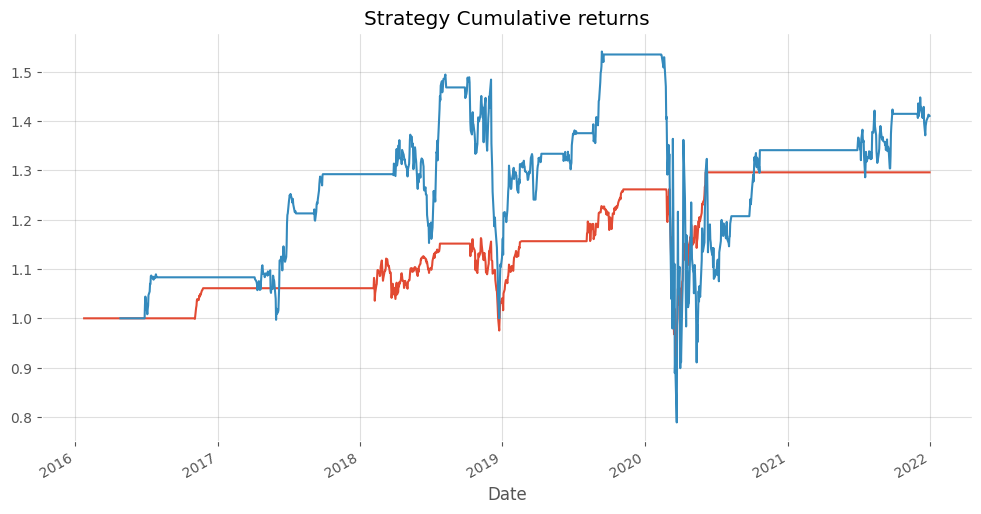

In [51]:
# Calculate all metrics for both strategies
df_lst = [spy, jpm]
tickers = ['SPY', 'JPM']
res_dct = {}

for ticker, df in zip(tickers, df_lst):
    res_dct[ticker] = {
        'sharpe': get_sharpe(df['strategy_returns']),
        'sortino': get_sortino_ratio(df['strategy_returns']),
        'max_drawdown': get_drawdowns(df['cum_strategy_returns']),
        'cagr': get_cagr(df['cum_strategy_returns']),
        'calmar': get_cagr(df['cum_strategy_returns']) / get_drawdowns(df['cum_strategy_returns']),
    }

    df['cum_strategy_returns'].plot(figsize=[12,6])

plt.title('Strategy Cumulative returns')
plt.show()


In [52]:
# Create comparison table
res_df = pd.DataFrame(res_dct)

In [53]:
res_df

,SPY,JPM
sharpe,0.303,0.158
sortino,0.421,0.235
max_drawdown,-0.283,-0.488
cagr,0.045,0.062
calmar,-0.158,-0.128


### <font color = red> Answer 4 </font>

    RSI Strategy (ETF_A - SPY):
    - Sharpe Ratio: ____________
    - Sortino Ratio: ____________
    - Maximum Drawdown: ____________%
    - CAGR: ____________%
    - Calmar Ratio: ____________
    
    Triple MA Strategy (Stock_A - JPM):
    - Sharpe Ratio: ____________
    - Sortino Ratio: ____________
    - Maximum Drawdown: ____________%
    - CAGR: ____________%
    - Calmar Ratio: ____________
    
    Better strategy (risk-adjusted): ____________
    
    Information Ratio: ____________

    Better strategy (risk-adjusted): SPY - RSI
    
    Information Ratio: ____________

***
# SECTION B: Supervised Machine Learning
***

##  <font color = blue> 👉 Question 5. </font> Feature Engineering for ETF Returns Prediction (25 points)

### Build a supervised learning model to predict the **5-day forward returns** of **ETF_B (QQQ)**.

### Feature Engineering Requirements:

**Target Variable (Y)**:
- 5-day forward return of QQQ
- Formula: `(price[t+5] - price[t]) / price[t]`

**Predictor Variables (X)**:

*Lagged Returns (QQQ)*:
- 5-day lagged return
- 10-day lagged return
- 20-day lagged return
- 60-day lagged return

*Technical Indicators (QQQ)*:
- 10-day SMA
- 20-day SMA
- 50-day SMA
- 14-day RSI
- 20-day Bollinger Band Width: `(Upper Band - Lower Band) / SMA`
  - Upper Band = SMA + (2 × std)
  - Lower Band = SMA - (2 × std)

*Market Features*:
- 5-day return of SPY (from ETF_A data)
- 20-day rolling correlation between QQQ and SPY
- 20-day rolling volatility of QQQ (annualized)

### Tasks:

a) Engineer all required features

b) Handle missing values by dropping rows with NaN

c) Split data: 75% training (first 75% chronologically), 25% testing

d) Report the shape and date ranges of training and testing sets

e) Display summary statistics of the feature matrix

### Below are the lines of code that lead to an answer:

In [ ]:
# Feature engineering code here
target = 'QQQ'
stock_tickers = [
    "QQQ", "SPY"   # Stocks
]


sub_df_list = []


# lagged five-day, 15-day, 30-day, and 60-day returns of NFLX.
lag_list = [5, 10, 20, 60]
df_rets = stock_data[[target]].copy()

for lag in lag_list:
    df_rets[f'{target}_ret_{lag}'] = df_rets[target].pct_change(lag).shift(1)
    
df_rets = df_rets.drop(columns=target)

sub_df_list.append(df_rets)

# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    df = df.copy()
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

sma_list = [10, 20, 50]
df_sma = get_sma(stock_data[[target]].copy(), sma_list).drop(columns=target)

sub_df_list.append(df_sma)

# get RSI
def get_rsi(df, period_list):
    """
    Calculate RSI (Relative Strength Index)
    
    Parameters:
    data: pandas df of closing price
    period: RSI period (default [10, 20, 200])
    
    Returns:
    pandas df with RSI values
    """
    df = df.copy()
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()    # start from period + 1 since diff() makes first NaN
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi

    return df

rsi_list = [14]
df_rsi = get_rsi(stock_data[[target]].copy(), rsi_list).drop(columns=target)

sub_df_list.append(df_rsi)

def get_bollinger_strategy(df, 
                              window = 20,
                              num_std = 2):
    """
    Create a Bollinger Band mean-reversion trading strategy
    """
    # get sma
    def get_sma_(df, sma_list, min_periods):
        """
        Take DF and given list of SMA to enrich df when stock price is in first column
        """
        for window in sma_list:
            df[f"sma_{window}"] =\
            (
                df[df.columns[0]]
                .rolling(window = window,
                        min_periods = min_periods,
                        center=False)
                .mean()
            )

        return df
    df = df.copy()
    df = get_sma_(df, [window], window)
    std = df[df.columns[0]].rolling(window).std()
    df = df.dropna()
    # print(df[f'sma_{window}'])
    df['upper'] = df[f'sma_{window}'] + num_std * std
    df['lower'] = df[f'sma_{window}'] - num_std * std

    df['positions'] =\
    (
        np.where(
            df[df.columns[0]] < df['lower'], 1, 
                np.where(
                    df[df.columns[0]] > df['upper'], 0, 
                        np.where(
                            (df[df.columns[0]] < df[f'sma_{window}']) & 
                            (df[df.columns[0]] > df[f'sma_{window}']).shift(1), 0,
                                np.where(
                                    (df[df.columns[0]] > df[f'sma_{window}']) & 
                                    (df[df.columns[0]] < df[f'sma_{window}']).shift(1), 0, np.nan
                                )
                        )
                )
        )
    )
    df['positions'] = df['positions'].ffill().shift(1).fillna(0)
    
    return df

# aapl = get_bollinger_strategy(aapl.dropna(), 20, 2)
df_boll = get_bollinger_strategy(stock_data[[target]].copy(), 20, 2).drop(columns=target)
df_boll['boll'] = (df_boll['upper'] - df_boll['lower']) / df_boll['sma_20']
df_boll = df_boll[['boll']]

sub_df_list.append(df_boll)


# 5 day lags for all stocks
df_rets = stock_data[[ticker for ticker in stock_tickers if ticker != target]].copy() # remove target
lag = 5
df_rets = df_rets.pct_change(lag).shift(1).rename(columns={f'{ticker}':f'{ticker}_ret_{lag}' for ticker in stock_tickers})

sub_df_list.append(df_rets)

# correlation of QQQ and SPY
spy_qqq_corr = stock_data['SPY'].rolling(20).corr(stock_data['QQQ']).to_frame('spy-qqq_corr')
sub_df_list.append(spy_qqq_corr)

# 20 day rolling vol of QQQ  
qqq_vol = (stock_data['QQQ'].pct_change().rolling(20).std() * np.sqrt(252)).to_frame('QQQ_vol')
sub_df_list.append(qqq_vol)

sub_df_list.append(qqq_vol)


# get target forward returns with lag
# y parameter
def get_target_parameter(df, target, fwd=5, lag=1):
    df_fwd_rets = df[[target]].copy()
    df_fwd_rets[f"{target}_fwd_rets"] = df_fwd_rets.pct_change(fwd).shift(-fwd-lag) 
                            # get fwd rets, shift by same amount, only trade day after signal computed
    return df_fwd_rets.drop(columns=target)

df_fwd_rets = get_target_parameter(stock_data, target, fwd=5, lag=1)

sub_df_list.append(df_fwd_rets)


In [82]:
# correlation of QQQ and SPY
df_corr = stock_data['SPY'].pct_change()\
                            .rolling(20)\
                            .corr(stock_data['QQQ']\
                                .pct_change())\
                            .to_frame('spy-qqq_corr')
display(df_corr)
# 20 day rolling vol of QQQ
qqq_vol = (
            stock_data['QQQ'].pct_change()
                            .rolling(20)
                            .std() * np.sqrt(252)
            ).to_frame('QQQ_vol')
display(qqq_vol)

,spy-qqq_corr
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,NaN
...,...
2021-12-27,0.926
2021-12-28,0.926
2021-12-29,0.938


,QQQ_vol
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,NaN
...,...
2021-12-27,0.262
2021-12-28,0.252
2021-12-29,0.246


In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [76]:
# combine df
df_combined =\
(
    pd.concat(sub_df_list,axis=1)
)
# fill forward for NaN
df_combined =\
(
    df_combined.ffill().dropna()
)

# Prepare features and target
X = df.drop(columns=[f'{target}_fwd_rets'])
y = df[f'{target}_fwd_rets']  # Note: removed extra brackets for cleaner y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=627, shuffle=False
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
# Handle missing values
X

Ticker,QQQ_ret_5,QQQ_ret_10,QQQ_ret_20,QQQ_ret_60,sma_10,sma_20,sma_50,rsi_14,boll,SPY_ret_5,spy-qqq_corr,QQQ_vol
Date,,,,,,,,,,,,
2016-04-01,0.018,0.018,0.035,0.000,101.124,99.884,96.739,70.616,0.066,0.011,0.979,0.110
2016-04-04,0.029,0.029,0.048,0.013,101.364,100.098,96.914,67.557,0.069,0.019,0.980,0.112
2016-04-05,0.026,0.024,0.043,0.019,101.466,100.293,97.016,60.441,0.067,0.015,0.974,0.116
2016-04-06,0.000,0.010,0.040,0.041,101.704,100.611,97.179,66.800,0.065,-0.005,0.963,0.121
2016-04-07,0.012,0.024,0.066,0.067,101.877,100.825,97.295,57.897,0.059,0.002,0.946,0.135
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,0.027,0.009,-0.003,0.106,381.857,382.492,380.541,59.143,0.064,0.012,0.773,0.262
2021-12-28,0.050,0.015,0.033,0.129,382.818,382.610,381.189,57.486,0.066,0.038,0.829,0.252
2021-12-29,0.055,0.025,0.006,0.116,384.170,383.012,381.762,57.431,0.069,0.048,0.894,0.246


In [79]:
# Train-test split (75-25)

In [65]:
# Summary statistics

### <font color = red> Answer 5 </font>

    Total number of features: ____________
    
    Total observations after dropping NaN: ____________
    
    Training set:
    - Shape: (____________, ____________)
    - Date range: ____________ to ____________
    
    Testing set:
    - Shape: (____________, ____________)
    - Date range: ____________ to ____________
    
    Feature with highest correlation to target: ____________
    Correlation value: ____________

In [66]:
# TRAIN TEST SPLIT INFO

print(f"    Features: {X.shape[1]}")
print(f"    Total obs after removing nulls: {X.shape[0]}")
print("    Training set:")
print(f"    - Shape: {X_train.shape}")
print(f"    Date range: {df.index[0]} to {df.index[len(X_train)-1]}")
print("    Test set:")
print(f"    - Shape: {X_test.shape}")
print(f"    Date range: {df.index[-len(X_test)]} to {df.index[-1]}")

    Features: 12
    Total obs after removing nulls: 1450
    Training set:
    - Shape: (1087, 12)
    Date range: 2016-04-01 00:00:00 to 2020-07-24 00:00:00
    Test set:
    - Shape: (363, 12)
    Date range: 2020-07-27 00:00:00 to 2021-12-31 00:00:00


In [67]:
df.corr()['QQQ_fwd_rets'].sort_values()

Ticker
rsi_14         -0.104
QQQ_ret_20     -0.101
QQQ_ret_60     -0.099
spy-qqq_corr   -0.030
QQQ_ret_10     -0.018
QQQ_ret_5      -0.005
SPY_ret_5       0.007
sma_10          0.008
sma_20          0.010
sma_50          0.019
boll            0.063
QQQ_vol         0.154
QQQ_fwd_rets    1.000
Name: QQQ_fwd_rets, dtype: float64

##  <font color = blue> 👉 Question 6. </font> Model Development and Comparison (35 points)

### Train and evaluate multiple regression models using the features from Question 5.

### Models to Train:

1. **Linear Regression**
2. **Ridge Regression** (alpha = 10.0)
3. **Lasso Regression** (alpha = 0.01)
4. **Elastic Net** (alpha = 0.01, l1_ratio = 0.5)
5. **K-Nearest Neighbors** (n_neighbors = 10)
6. **Decision Tree Regressor** (max_depth = 5)
7. **Random Forest Regressor** (n_estimators = 100, max_depth = 10)
8. **Gradient Boosting Regressor** (n_estimators = 100, max_depth = 3)

### Tasks:

a) Train all eight models on the training data

b) Make predictions on both training and testing sets

c) For each model, calculate:
   - Training MSE
   - Testing MSE
   - Training R² score
   - Testing R² score
   - Training MAE (Mean Absolute Error)
   - Testing MAE

d) Create a comprehensive comparison table

e) Visualize model performance (bar chart of Test MSE)

f) Identify the top 3 performing models based on Test MSE

g) For the best model:
   - Create actual vs predicted scatter plot (test set)
   - Display feature importance (if available)
   - Calculate directional accuracy (% of times predicted sign matches actual sign)

### Below are the lines of code that lead to an answer:

In [68]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# establish metrics 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse_results = {}

def get_mse_train_test(model, X_train, y_train, X_test, y_test, name=None):
    """
    Compute MSE on train and test and store results in mse_results.
    If name is not provided, use model class name.
    """
    global mse_results
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    model_name = name or model.__class__.__name__
    if model_name == "GridSearchCV":
        model_name = str(type(model.best_estimator_)).split(".")[-1].replace("'>", "")
    

    mse_results[str(model_name)] = {
                                    'mse_train': mse_train, 
                                    'mse_test': mse_test,
                                    'r2_train': r2_train,
                                    'r2_test': r2_test,
                                    'mae_train': mae_train,
                                    'mae_test': mae_test
                                }

    print(f"Mean Squared Error (MSE) for {model_name}")
    print(f"MSE train: {mse_train:.6f}")
    print(f"MSE test: {mse_test:.6f}")
    print(f"R2 train: {r2_train:.6f}")
    print(f"R2 test: {r2_test:.6f}")
    print(f"MAE train: {r2_train:.6f}")
    print(f"MAE test: {r2_test:.6f}")

    return mse_train, mse_test, r2_train, r2_test


In [70]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha = 10.0),
    'Lasso': Lasso(alpha = 0.01),
    'Elastic Net': ElasticNet(alpha = 0.01, l1_ratio = 0.5),
    'KNN': KNeighborsRegressor(n_neighbors = 10),
    'Decision Tree': DecisionTreeRegressor(max_depth = 5, random_state = 627),
    'Random Forest': RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 627),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators = 100, max_depth = 3, random_state = 627)
}

In [71]:
# Train all models and collect results
for model_name, model in models.items():
    fit_model = model.fit(X_train_scaled, y_train)
    get_mse_train_test(fit_model, 
                   X_train_scaled, 
                   y_train, 
                   X_test_scaled,
                   y_test, 
                   name=model_name)

# Your code here

Mean Squared Error (MSE) for Linear Regression
MSE train: 0.000626
MSE test: 0.000914
R2 train: 0.065936
R2 test: -0.320001
MAE train: 0.065936
MAE test: -0.320001
Mean Squared Error (MSE) for Ridge
MSE train: 0.000635
MSE test: 0.000781
R2 train: 0.051799
R2 test: -0.128250
MAE train: 0.051799
MAE test: -0.128250
Mean Squared Error (MSE) for Lasso
MSE train: 0.000670
MSE test: 0.000695
R2 train: 0.000000
R2 test: -0.004593
MAE train: 0.000000
MAE test: -0.004593
Mean Squared Error (MSE) for Elastic Net
MSE train: 0.000670
MSE test: 0.000695
R2 train: 0.000000
R2 test: -0.004593
MAE train: 0.000000
MAE test: -0.004593
Mean Squared Error (MSE) for KNN
MSE train: 0.000386
MSE test: 0.000909
R2 train: 0.424142
R2 test: -0.313989
MAE train: 0.424142
MAE test: -0.313989
Mean Squared Error (MSE) for Decision Tree
MSE train: 0.000454
MSE test: 0.000805
R2 train: 0.322373
R2 test: -0.163767
MAE train: 0.322373
MAE test: -0.163767
Mean Squared Error (MSE) for Random Forest
MSE train: 0.000205
M

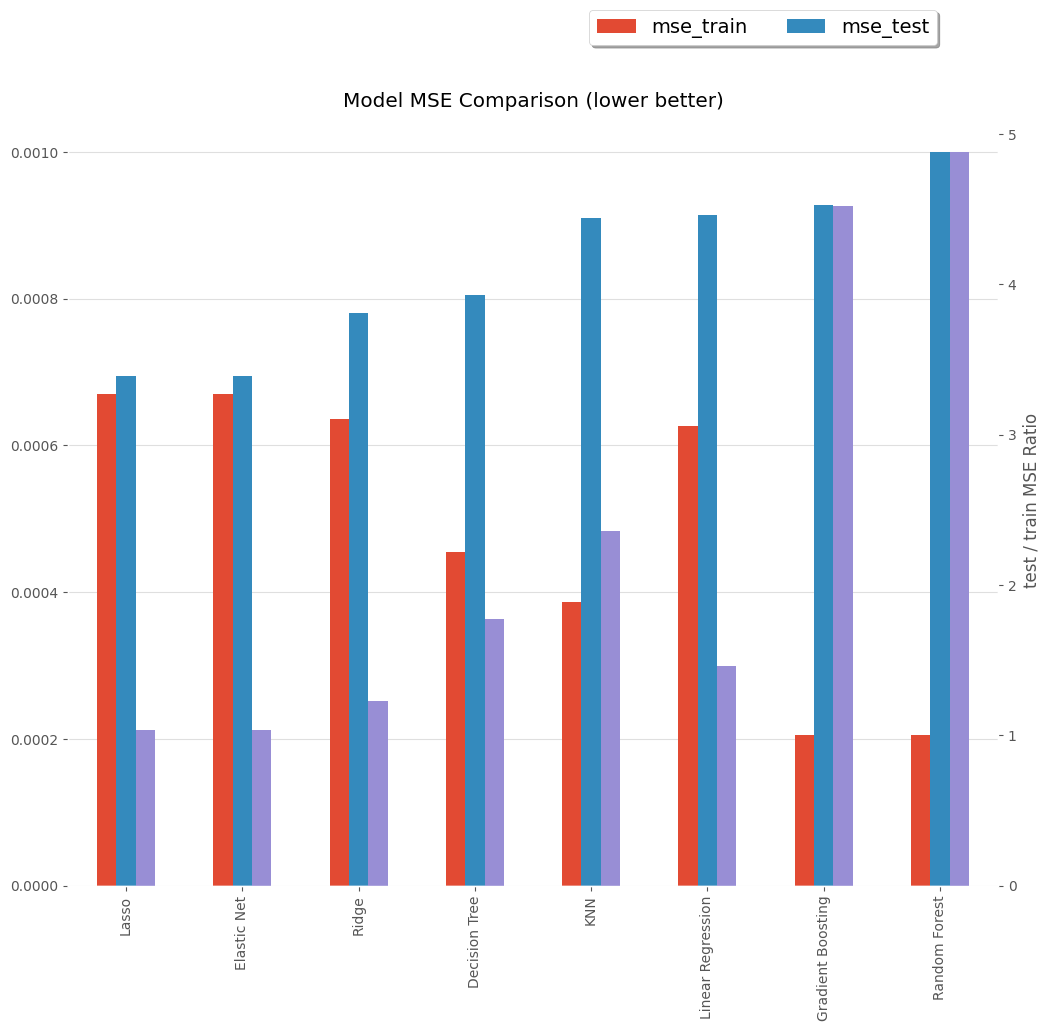

In [72]:
# get results DataFrame

## Create results dataframe
metrics = pd.DataFrame(mse_results).T.sort_values(by='mse_test')
metrics['mse_ratio'] = metrics['mse_test'] / metrics['mse_train']
display(metrics)

## Visualization of model comparison
ax =\
(
    metrics[['mse_train', 'mse_test', 'mse_ratio']].plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

In [73]:
# Visualize model comparison

metrics

,mse_train,mse_test,r2_train,r2_test,mae_train,mae_test,mse_ratio
Lasso,0.001,0.001,0.000,-0.005,0.018,0.020,1.038
Elastic Net,0.001,0.001,0.000,-0.005,0.018,0.020,1.038
Ridge,0.001,0.001,0.052,-0.128,0.018,0.023,1.229
Decision Tree,0.000,0.001,0.322,-0.164,0.015,0.021,1.774
KNN,0.000,0.001,0.424,-0.314,0.014,0.023,2.357
Linear Regression,0.001,0.001,0.066,-0.320,0.018,0.024,1.460
Gradient Boosting,0.000,0.001,0.694,-0.341,0.011,0.024,4.521
Random Forest,0.000,0.001,0.694,-0.444,0.011,0.025,4.879


In [58]:
# Identify top 3 models


In [59]:
# Best model analysis: actual vs predicted

In [60]:
# Feature importance (if available)

In [61]:
# Calculate directional accuracy
def directional_accuracy(y_true, y_pred):
    """
    Calculate percentage of times predicted direction matches actual direction
    """
    # Your code here
    
    return accuracy

### <font color = red> Answer 6 </font>

    Top 3 Models (by Test MSE):
    1. ____________ (MSE: ____________)
    2. ____________ (MSE: ____________)
    3. ____________ (MSE: ____________)
    
    Best Model: ____________
    - Train MSE: ____________
    - Test MSE: ____________
    - Train R²: ____________
    - Test R²: ____________
    - Directional Accuracy: ____________%
    
    Top 3 Most Important Features (if applicable):
    1. ____________
    2. ____________
    3. ____________
    
    Evidence of overfitting: ____________
    (Compare Train vs Test performance)

In [62]:
print(f"top 3 models")
print(metrics.iloc[:3])
print('best model')
print(metrics.iloc[0])

top 3 models
             mse_train  mse_test  r2_train  r2_test  mae_train  mae_test  \
Lasso            0.001     0.001     0.000   -0.005      0.018     0.020   
Elastic Net      0.001     0.001     0.000   -0.005      0.018     0.020   
Ridge            0.001     0.001     0.052   -0.128      0.018     0.023   

             mse_ratio  
Lasso            1.038  
Elastic Net      1.038  
Ridge            1.229  
best model
mse_train    0.001
mse_test     0.001
r2_train     0.000
r2_test     -0.005
mae_train    0.018
mae_test     0.020
mse_ratio    1.038
Name: Lasso, dtype: float64


In [63]:
lasso = models['Lasso'].fit(X_train_scaled, y_train)

In [64]:
lasso.coef_

array([ 0.,  0., -0., -0., -0., -0.,  0., -0.,  0.,  0., -0.,  0.])

Model is heavily biased

***
# SECTION C: Unsupervised Learning
***

##  <font color = blue> 👉 Question 7. </font> PCA for Sector ETF Analysis (30 points)

### Download data for the following sector ETFs from **January 1, 2017 to December 31, 2022**:

**Sector ETFs**: XLF, XLE, XLK, XLV, XLI, XLY, XLP, XLU, XLRE

(Financials, Energy, Technology, Healthcare, Industrials, Consumer Discretionary, Consumer Staples, Utilities, Real Estate)

### Tasks:

a) Download Adjusted Close prices for all 9 sector ETFs

b) Calculate daily returns and standardize using `StandardScaler`

c) Apply PCA and determine:
   - How many components explain 80% of variance
   - How many components explain 95% of variance

d) Report the explained variance ratio for each of the first 6 components

e) Create a scree plot with cumulative explained variance

f) Create a loading plot (heatmap) showing how each ETF loads on the first 4 PCs

g) Transform data using 3 principal components

h) Create a 3D scatter plot of the first three principal components

i) Interpret: Which sector(s) drive PC1? Which drive PC2?

### Below are the lines of code that lead to an answer:

In [89]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [90]:
# Download sector ETF data
sector_etfs = ['XLF', 'XLE', 'XLK', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLRE']

# Your code here

In [91]:
stock_data = pd.read_csv('group2_sector_etfs.csv', 
                        index_col=0, 
                        parse_dates=True,
                        header=[0,1]
                        )

fltr = [x for x in stock_data.columns if x[1] == 'Adj Close']

stock_data = stock_data[fltr]
stock_data = stock_data.droplevel('Price',axis=1).ffill()
stock_data = stock_data.loc['2017-01-01': '2023-01-01']
returns_df = stock_data.pct_change().dropna()

In [92]:
x = returns_df
RANDOM_SEED=42
NumEigenValues = 10
NumComponents = 4
x_train_raw, x_test_raw = train_test_split(x, test_size=0.2, random_state=RANDOM_SEED, shuffle=False)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw) 
x_test = scaler.transform(x_test_raw)       # keep raw for actual resutls later

pca = PCA()
PrincipalComponent = pca.fit(x_train)

def PCWeights(pca_):

    weights = pd.DataFrame()

    for i in range(len(pca_.components_)
                  ):
        # w = pca_.components_[i] - pca_.components_[i].mean()
        # w = w / sum(abs(w))
        weights["weights_{}".format(i)] = pca_.components_[i] / sum(pca_.components_[i])

    weights = weights.values.T
    return weights # Team, be careful with indentation    
    # return w # Team, be careful with indentation


weights = PCWeights(pca) 


topPortfolios =\
(
    pd
    .DataFrame(pca.components_[ : NumComponents],
               columns = x.columns)
)

eigen_portfolios =\
(
    topPortfolios
    .div(topPortfolios.sum(axis=1), # normalising step
         axis = 0)
)

eigen_portfolios.index = [f"Portfolio {i}" for i in range(NumComponents)
                         ]
np.sqrt(pca.explained_variance_)

array([2.542, 0.948, 0.761, 0.533, 0.464, 0.441, 0.409, 0.335, 0.307])

,Explained Variance
0,71.74%
1,81.73%
2,88.16%
3,91.31%
4,93.70%
5,95.86%
6,97.71%
7,98.96%
8,100.00%


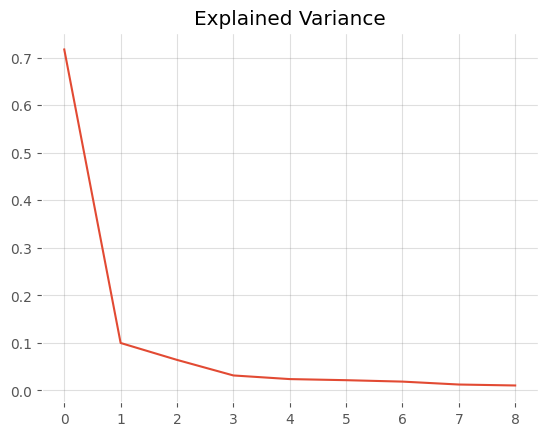

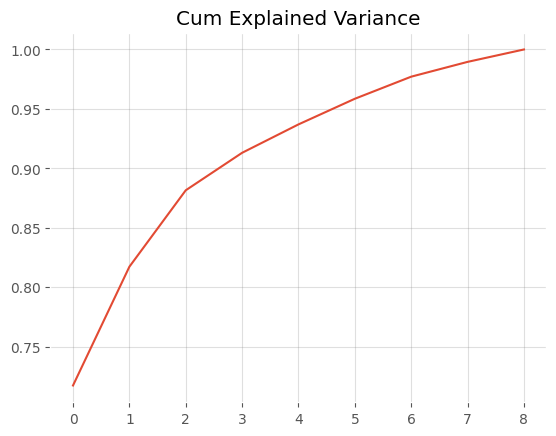

In [94]:
display(
    pd
    .Series(np
           .cumsum(pca
                   .explained_variance_ratio_)
           )
    .to_frame("Explained Variance")
    .head(NumEigenValues)
    .style
    .format("{:,.2%}".format)
)

# Scree plot with individual variance
pd.Series(pca.explained_variance_ratio_).plot()
plt.title('Explained Variance')
plt.show()


# Scree plot with cumulative variance
pd.Series(np\
        .cumsum(pca
                .explained_variance_ratio_)
        ).plot()
plt.title('Cum Explained Variance')
plt.show()



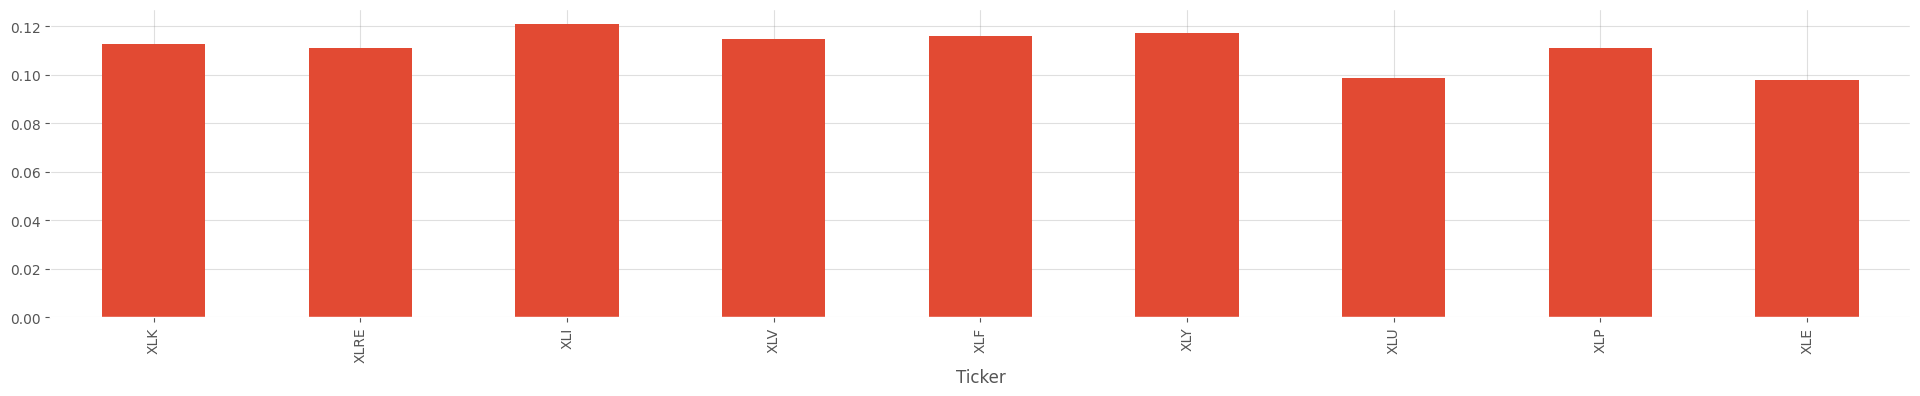

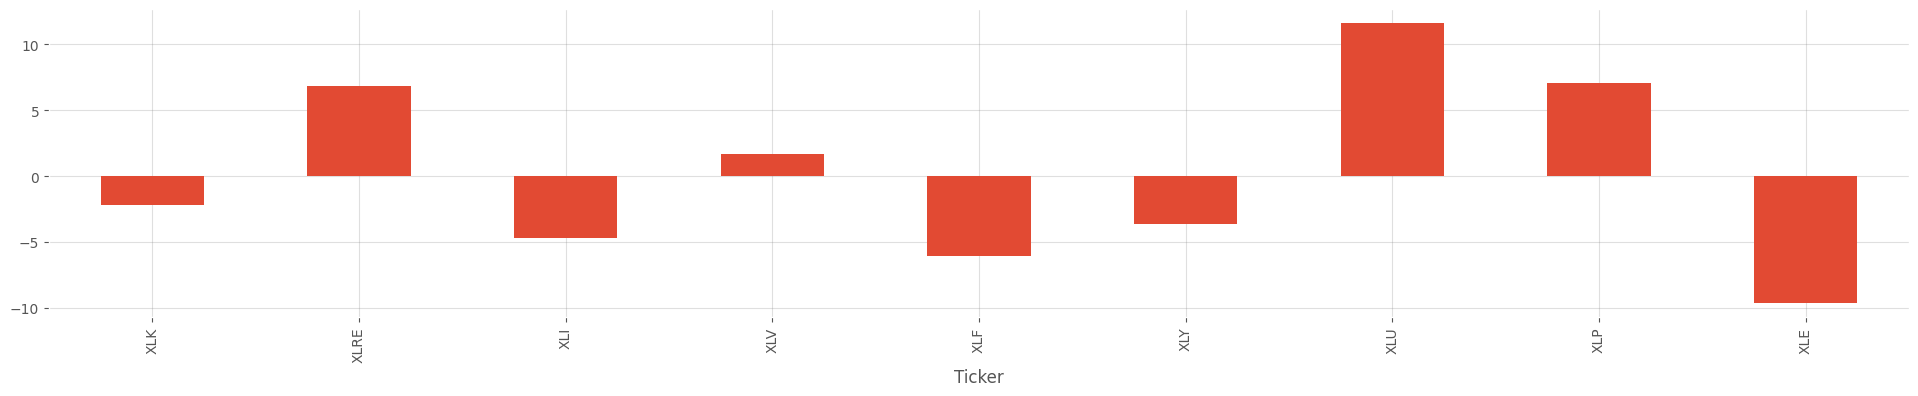

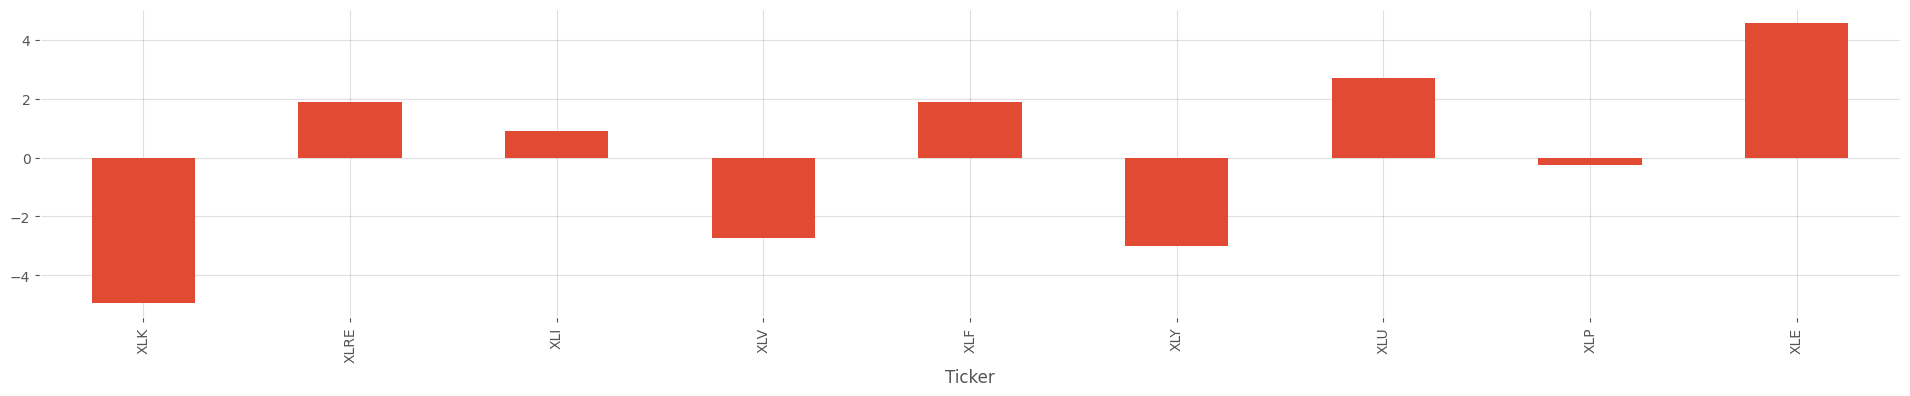

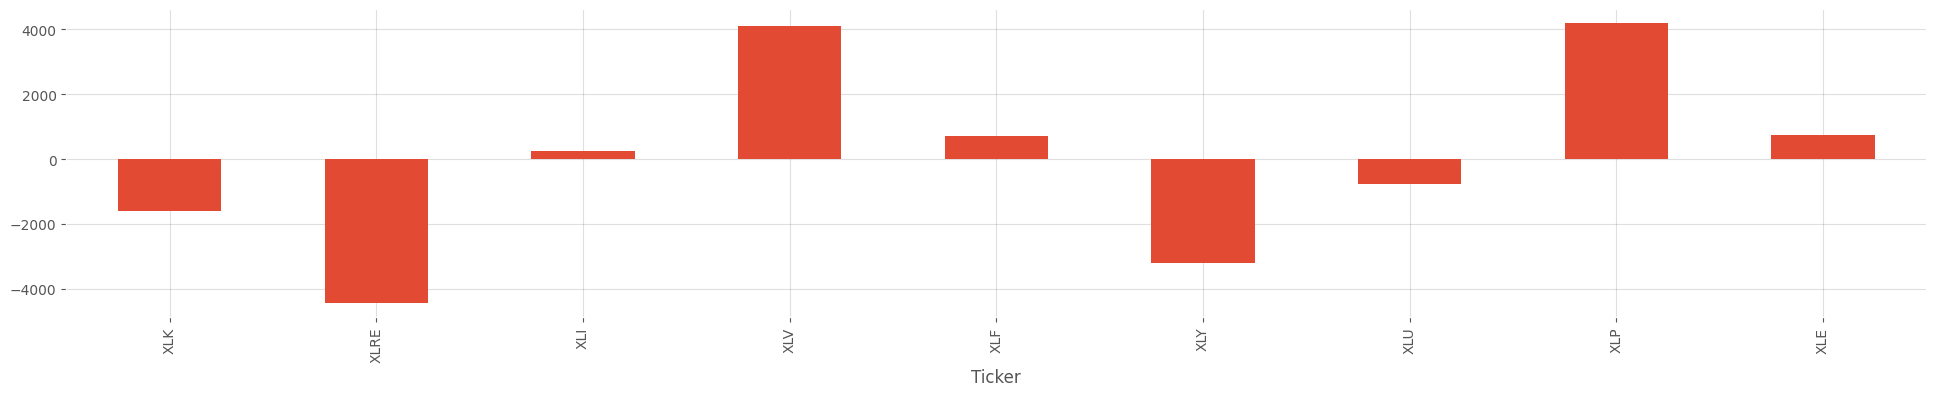

In [72]:
# Transform to 3 components and create 3D plot
# plot weights of PCs
for weight in weights[:4]:
    pd.Series(weight,index=returns_df.columns).plot(kind='bar',figsize=[24,4])
    plt.show()

### <font color = red> Answer 7 </font>

    Components for 80% variance: ____________
    Components for 95% variance: ____________
    
    Explained Variance Ratios:
    - PC1: ____________%
    - PC2: ____________%
    - PC3: ____________%
    - PC4: ____________%
    - PC5: ____________%
    - PC6: ____________%
    
    Total variance explained by first 3 PCs: ____________%
    
    PC1 Interpretation:
    - Highest loading sectors: ____________
    - Represents: ____________
    
    PC2 Interpretation:
    - Highest loading sectors: ____________
    - Represents: ____________

In [73]:
print(f"    Number of components for 80% variance: {np.argmax(np.cumsum(pca.explained_variance_ratio_) > .8) + 1}")    
print(f"    Number of components for 90% variance: {np.argmax(np.cumsum(pca.explained_variance_ratio_) > .9) + 1}")    
print(f"    Explained variance ratios (first 6 components):")
for i, var in enumerate(pca.explained_variance_ratio_[:6], start=1):
    print(f"    - PC{i}: {var:.2%}")
print(f"    Cumulative variance explained by first 3 components: {np.cumsum(pca.explained_variance_ratio_)[2]:.2%}")

    Number of components for 80% variance: 2
    Number of components for 90% variance: 4
    Explained variance ratios (first 6 components):
    - PC1: 71.74%
    - PC2: 9.99%
    - PC3: 6.43%
    - PC4: 3.15%
    - PC5: 2.39%
    - PC6: 2.16%
    Cumulative variance explained by first 3 components: 88.16%


##  <font color = blue> 👉 Question 8. </font> K-Means Clustering for Portfolio Construction (35 points)

### Using the same 9 sector ETFs from Question 7, perform K-Means clustering to create diversified portfolio groups.

### Tasks:

a) Calculate for each ETF:
   - Annualized return (mean daily return × 252)
   - Annualized volatility (std daily return × √252)
   - Sharpe ratio (return / volatility)

b) Create a feature matrix with [Return, Volatility, Sharpe]

c) Standardize the features

d) Use **Elbow method** to test k from 2 to 8

e) Use **Silhouette Score** to validate optimal k

f) Apply K-Means with optimal k

g) Visualize clusters in 2D (Return vs Volatility) with Sharpe ratio as point size

h) For each cluster, report:
   - Member ETFs
   - Average return
   - Average volatility
   - Average Sharpe ratio

i) Based on clustering, recommend a portfolio allocation strategy

j) Calculate the within-cluster sum of squares (WCSS) for your optimal k

### Below are the lines of code that lead to an answer:

In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [75]:
# TODO: get_annual_returns dataframe
# prepare annual returns
ann_rets = stock_data.pct_change().mean() * 252
ann_vols = stock_data.pct_change().std() * np.sqrt(252)

df = \
(
    pd.DataFrame({'return': ann_rets, 'volatility': ann_vols})
)

# SCALED DATA FOR CLUSTERING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(df)

df = pd.DataFrame(data, columns=df.columns, index=df.index)

X = df.copy()

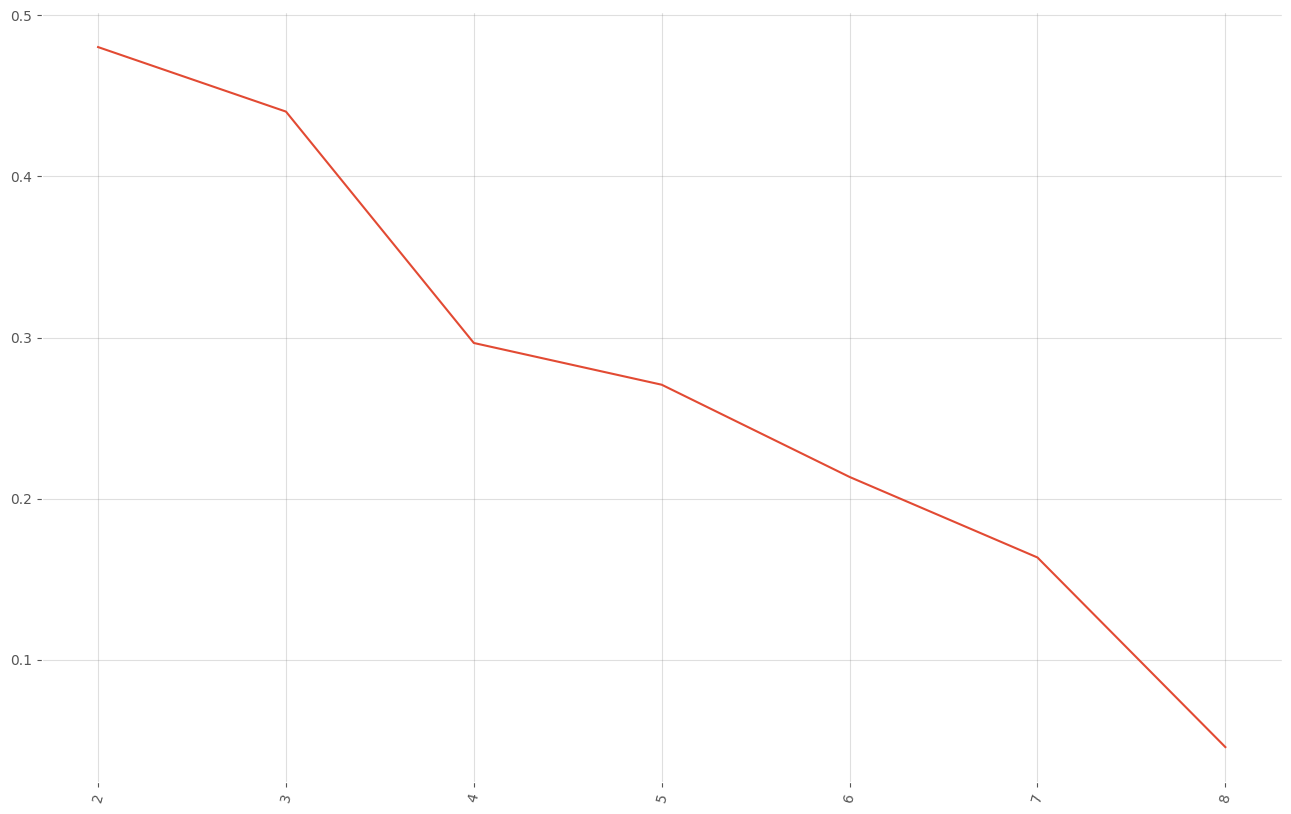

In [76]:
# Calculate performance metrics

# K-means Clustering - Silhouette Score Method
## get_kmeans clustering
# ----------------------------------------------------------------------------
# Silhouette score method
silhouette_ls = []
max_loop = len(X)

for k in range(2, max_loop):
        kmeans = KMeans(n_clusters = k,  
                        random_state = 627, 
                        n_init = 10)
        kmeans.fit(X)        
        silhouette_ls.append(silhouette_score(X, kmeans.labels_, random_state = 627)
                               )
        
fig = plt.figure(figsize=(16, 10)
                )

plt.plot(range(2, max_loop), silhouette_ls)

plt.xticks([i for i in range(2, max_loop)], 
           rotation=75)

plt.grid(True)
# ----------------------------------------------------------------------------

In [77]:
# Create and standardize feature matrix

In [78]:
# Visualize clusters (Return vs Volatility, sized by Sharpe)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_94915/3998128859.py:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "sg" (-> color='g'). The keyword argument will take precedence.
  plt.plot(centroids[:,0],


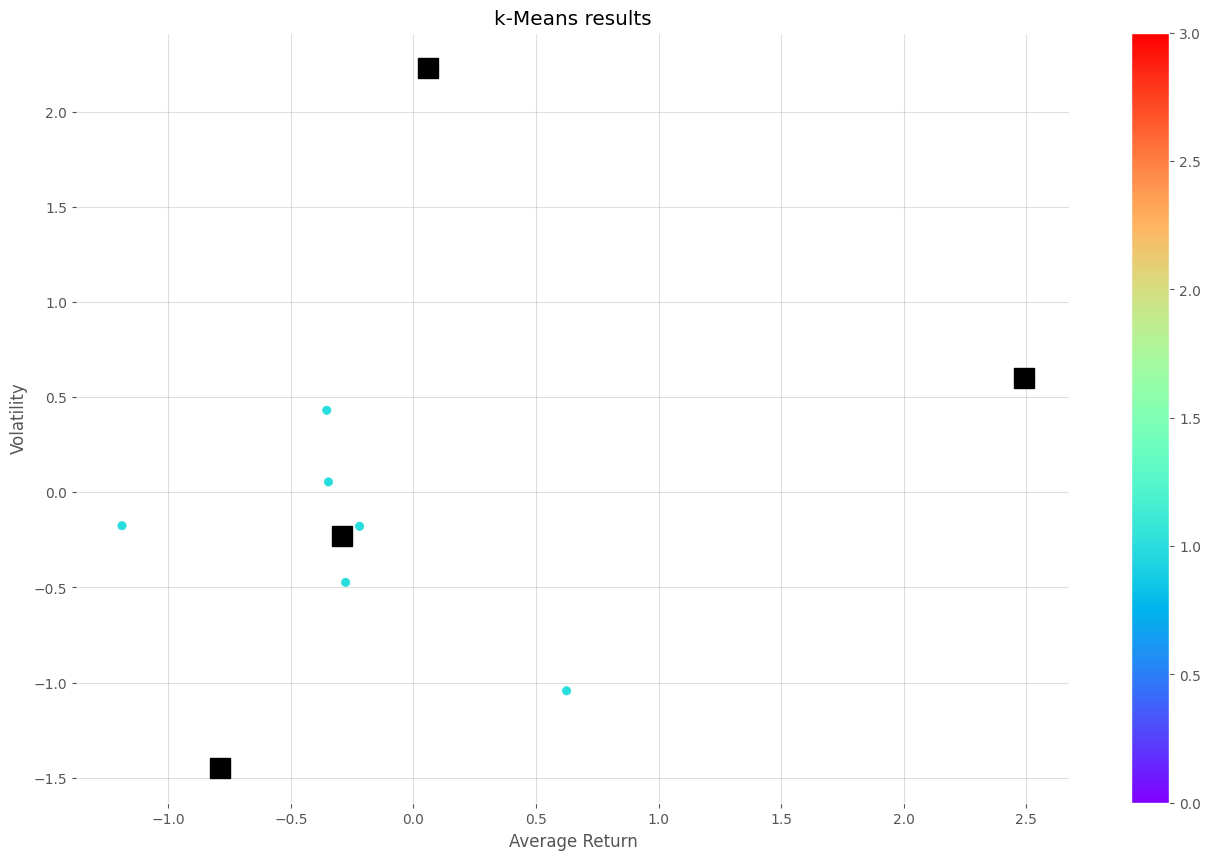

In [79]:
# Apply K-Means with optimal k
"""
Elbow method and pick optimal k based on silhouette
"""
from sklearn import cluster 

# Apply K-Means with optimal k
optimal_k = 4

# Fit with k-means
k_means = cluster.KMeans(n_clusters=optimal_k)
k_means.fit(X)

# plot 
## Visualize clusters
centroids = k_means.cluster_centers_

fig = plt.figure(figsize=(16,10)
                )

ax = fig.add_subplot(111)

scatter =\
(    
    ax
    .scatter(X.iloc[ : ,0], 
             X.iloc[ : ,1], 
             c = k_means.labels_, 
             cmap = "rainbow", 
             label = X.index)
)

ax.set_title("k-Means results")
ax.set_xlabel("Average Return")
ax.set_ylabel("Volatility")

plt.colorbar(scatter)

plt.plot(centroids[:,0], 
         centroids[:,1], 
         "sg", 
         markersize = 15, 
         color = "black")

# PLEASE NOTE THAT ALL THE RETURNS AND VOLS IN THIS PLOT ARE SCALED
##########################################

In [80]:
X

,return,volatility
Ticker,,
XLK,2.490,0.600
XLRE,-1.189,-0.175
XLI,-0.219,-0.178
XLV,0.625,-1.043
XLF,-0.354,0.431
XLY,-0.347,0.055
XLU,-0.277,-0.473
XLP,-0.790,-1.448
XLE,0.061,2.232


In [82]:
# Calculate cluster statistics


### <font color = red> Answer 8 </font>

    Optimal k (from Elbow): ____________
    Optimal k (from Silhouette): ____________
    
    Silhouette Score for optimal k: ____________
    WCSS for optimal k: ____________
    
    Cluster 0:
    - Members: ____________
    - Avg Return: ____________%
    - Avg Volatility: ____________%
    - Avg Sharpe: ____________
    
    Cluster 1:
    - Members: ____________
    - Avg Return: ____________%
    - Avg Volatility: ____________%
    - Avg Sharpe: ____________
    
    (Add more clusters as needed)
    
    Portfolio Allocation Strategy:
    ____________________________________________________________
    ____________________________________________________________

    Optimal k (from Elbow): 4
    Optimal k (from Silhouette): 4
    
    Silhouette Score for optimal k: .275
    WCSS for optimal k: ____________
    

In [83]:
print("    Cluster assignments:")
cluster_df = pd.DataFrame({'ticker': returns_df.columns, 'cluster': k_means.labels_})
for cluster_id in sorted(cluster_df['cluster'].unique()):
    tickers = cluster_df[cluster_df['cluster'] == cluster_id]['ticker'].tolist()
    print(f"    - Cluster {cluster_id}: {tickers} \n{X.loc[tickers].mean()}\nAve. Sharpe: {(X.loc[tickers]['return']/X.loc[tickers]['volatility']).mean()}\n\n")

    Cluster assignments:
    - Cluster 0: ['XLP'] 
return       -0.790
volatility   -1.448
dtype: float64
Ave. Sharpe: 0.5460427750819722


    - Cluster 1: ['XLRE', 'XLI', 'XLV', 'XLF', 'XLY', 'XLU'] 
return       -0.293
volatility   -0.231
dtype: float64
Ave. Sharpe: 0.13906536217367732


    - Cluster 2: ['XLK'] 
return       2.490
volatility   0.600
dtype: float64
Ave. Sharpe: 4.148412545214674


    - Cluster 3: ['XLE'] 
return       0.061
volatility   2.232
dtype: float64
Ave. Sharpe: 0.027335650122082777




##  <font color = blue> 👉 Question 9. </font> Hierarchical Clustering with Dendrogram (30 points)

### Perform agglomerative hierarchical clustering on the standardized feature matrix from Question 8.

### Tasks:

a) Compute linkage matrices using THREE different methods:
   - Ward linkage
   - Average linkage
   - Complete linkage

b) Create dendrograms for all three methods (side-by-side comparison)

c) For Ward linkage, cut the dendrogram at different heights to create:
   - 2 clusters
   - 3 clusters
   - 4 clusters

d) Compare hierarchical clustering (3 clusters) with K-Means (if k=3)

e) Create a comparison table showing cluster assignments from both methods

f) Calculate the Adjusted Rand Index between hierarchical and K-Means results

g) Interpret: Which two ETFs are most similar (merge first in dendrogram)?

h) Which linkage method creates the most balanced clusters?

### Below are the lines of code that lead to an answer:

In [84]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score

In [85]:
# Compute linkage matrices for three methods

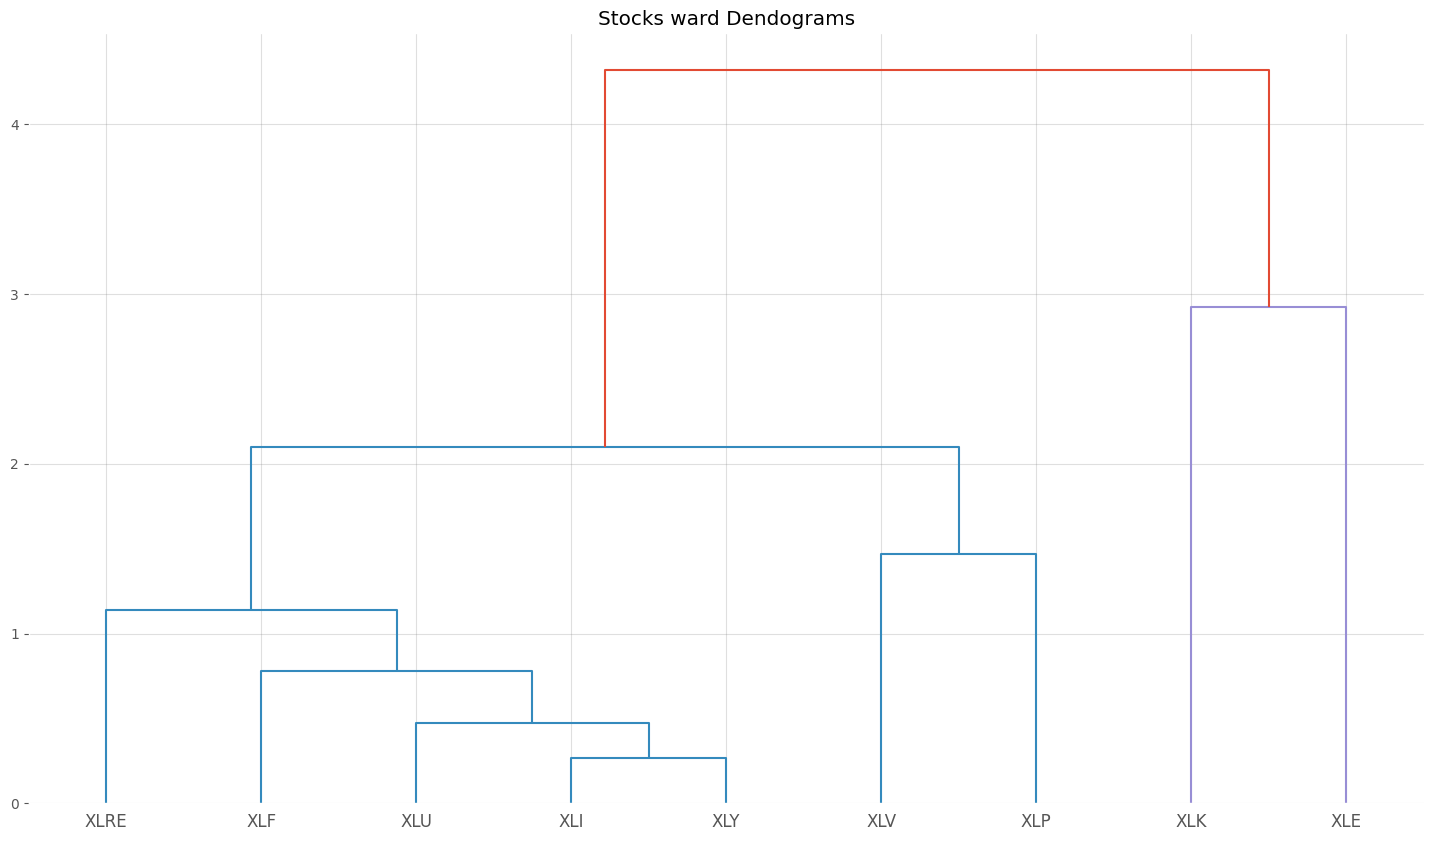

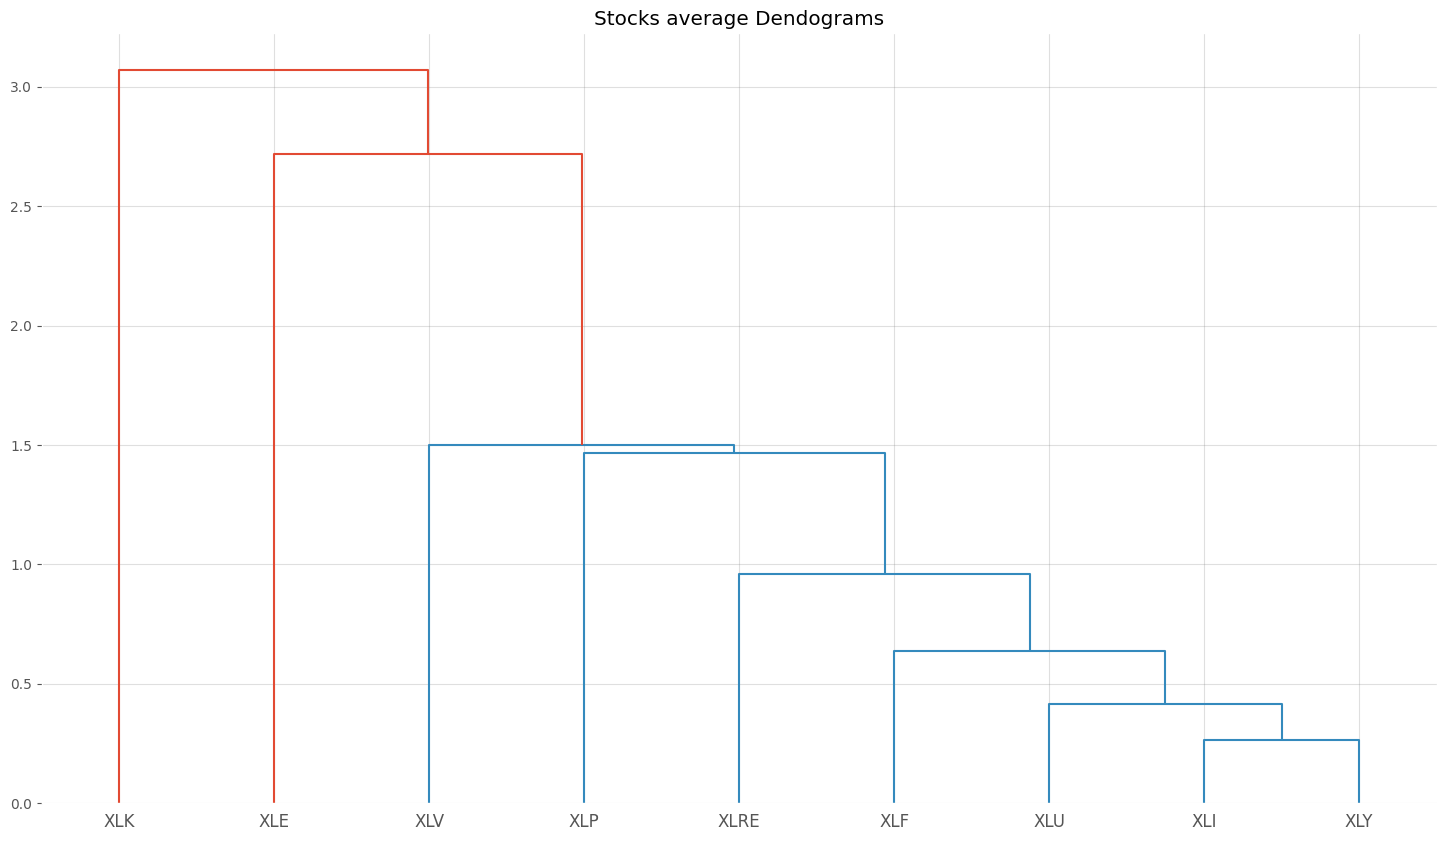

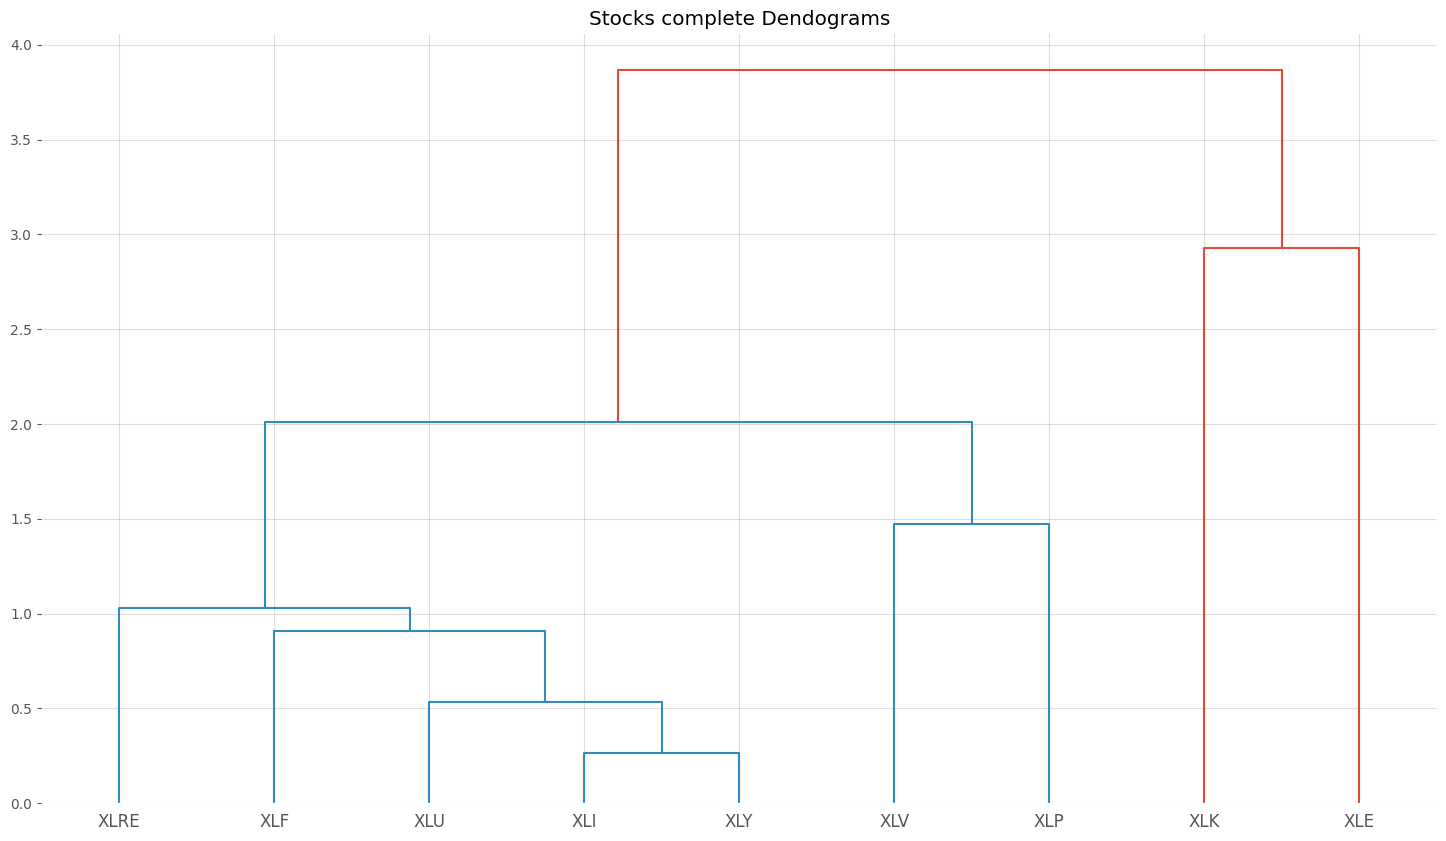

array([2, 1, 3], dtype=int32)

In [86]:
# ----------------------------------------------------------------------------
# agnes get_agnes agglo
# ----------------------------------------------------------------------------

# model fit
from scipy.cluster.hierarchy import dendrogram, linkage, ward
#Calulate linkage
for method in ['ward', 'average', 'complete']:
    Z = linkage(X, 
                method = method)
    # Plot Dendogram

    plt.figure(figsize=(18, 10)
            )
    plt.title(f"Stocks {method} Dendograms")

    dendrogram(Z, labels = X.index)

    plt.show()

from sklearn.cluster import AgglomerativeClustering
# from sklearn.cluster import KMeans, AgglomerativeClustering,AffinityPropagation, DBSCAN
from scipy.cluster.hierarchy import fcluster
# from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
# from scipy.spatial.distance import pdist
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn import cluster, covariance, manifold

# choose a cluster from the longest vertical line
distance_threshold = 2.5

clusters = fcluster(Z, distance_threshold, criterion='distance')

chosen_clusters = pd.DataFrame(data=clusters, 
                               columns=['cluster']
                              )
display(chosen_clusters['cluster'].unique())

# do the transformation to assign clusters
# agglomarative clustering
nclust = 3

hc = AgglomerativeClustering(n_clusters = nclust, 
                             linkage = "ward")

clust_labels1 = hc.fit_predict(X)

In [87]:
# Cut Ward dendrogram at different levels
clust_labels1

array([2, 0, 0, 0, 0, 0, 0, 0, 1])

In [88]:
# Compare with K-Means (if k=3)


In [89]:
# Calculate Adjusted Rand Index

In [90]:
res_df = X.copy()

res_df['kmeans'] = k_means.labels_
res_df['agglo'] = clust_labels1

In [91]:
res_df

,return,volatility,kmeans,agglo
Ticker,,,,
XLK,2.490,0.600,2,2
XLRE,-1.189,-0.175,1,0
XLI,-0.219,-0.178,1,0
XLV,0.625,-1.043,1,0
XLF,-0.354,0.431,1,0
XLY,-0.347,0.055,1,0
XLU,-0.277,-0.473,1,0
XLP,-0.790,-1.448,0,0
XLE,0.061,2.232,3,1


In [92]:
# Visualize comparison

### <font color = red> Answer 9 </font>

    Hierarchical Clustering (Ward, 3 clusters):
    - Cluster 1: ____________
    - Cluster 2: ____________
    - Cluster 3: ____________
    
    Hierarchical Clustering (Ward, 4 clusters):
    - Cluster 1: ____________
    - Cluster 2: ____________
    - Cluster 3: ____________
    - Cluster 4: ____________
    
    Most similar ETFs (merge first): ____________ and ____________
    
    Adjusted Rand Index (Hierarchical vs K-Means): ____________
    
    Most balanced linkage method: ____________
    
    Interpretation:
    ____________________________________________________________
    ____________________________________________________________

##  <font color = blue> 👉 Question 10. </font> t-SNE for Nonlinear Dimensionality Reduction (25 points)

### Apply t-SNE to visualize the sector ETF relationships in 2D space.

### Tasks:

a) Use the daily returns (not standardized) from Question 7

b) Apply t-SNE with the following parameter sets:
   - **Setting 1**: perplexity=3, learning_rate=200
   - **Setting 2**: perplexity=5, learning_rate=200
   - **Setting 3**: perplexity=8, learning_rate=200

c) Create three t-SNE visualizations, colored by K-Means cluster labels

d) Compare t-SNE results with PCA (2D projection from Question 7)

e) Which perplexity value gives the best separation?

f) Do the t-SNE clusters align with K-Means labels?

g) Create a combined visualization showing:
   - PCA 2D projection (left panel)
   - Best t-SNE projection (right panel)
   - Both colored by K-Means labels

h) Explain which method (PCA vs t-SNE) better captures sector relationships

### Below are the lines of code that lead to an answer:

In [93]:
from sklearn.manifold import TSNE

In [94]:
df['cluster'] = clust_labels1

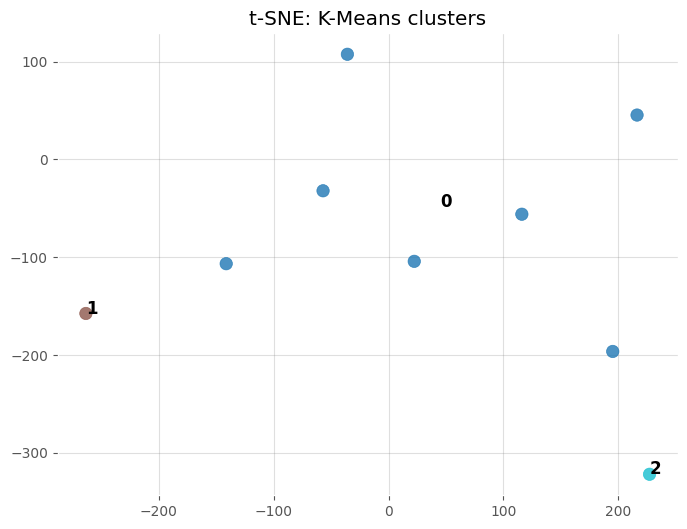

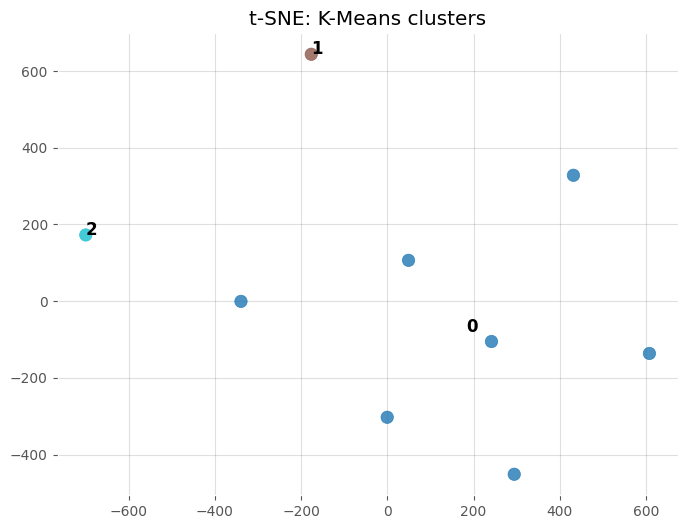

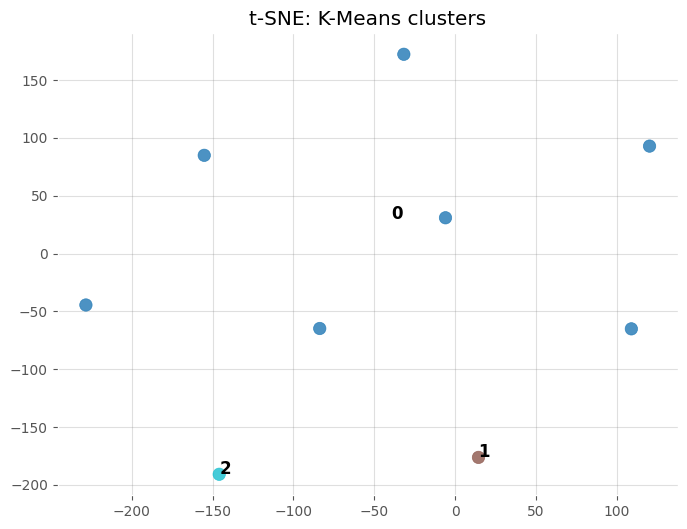

In [95]:
for perp in [3, 5,8]:
    # Apply t-SNE with different perplexity values
    # Fit t-SNE (2D projection)
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, random_state=42)
    tsne_results = tsne.fit_transform(X)

    # Add results to df
    df['tsne_1'] = tsne_results[:, 0]
    df['tsne_2'] = tsne_results[:, 1]

    # Visualize t-SNE with cluster labels
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        df['tsne_1'],
        df['tsne_2'],
        c=df['cluster'],
        cmap='tab10',
        s=80,
        alpha=0.8
    )

    # optional: show cluster centroids in tsne space
    for c in sorted(df['cluster'].unique()):
        x = df[df['cluster']==c]['tsne_1'].mean()
        y = df[df['cluster']==c]['tsne_2'].mean()
        plt.text(x, y, str(c), fontsize=12, weight='bold')

    plt.title('t-SNE: K-Means clusters')
    plt.show()

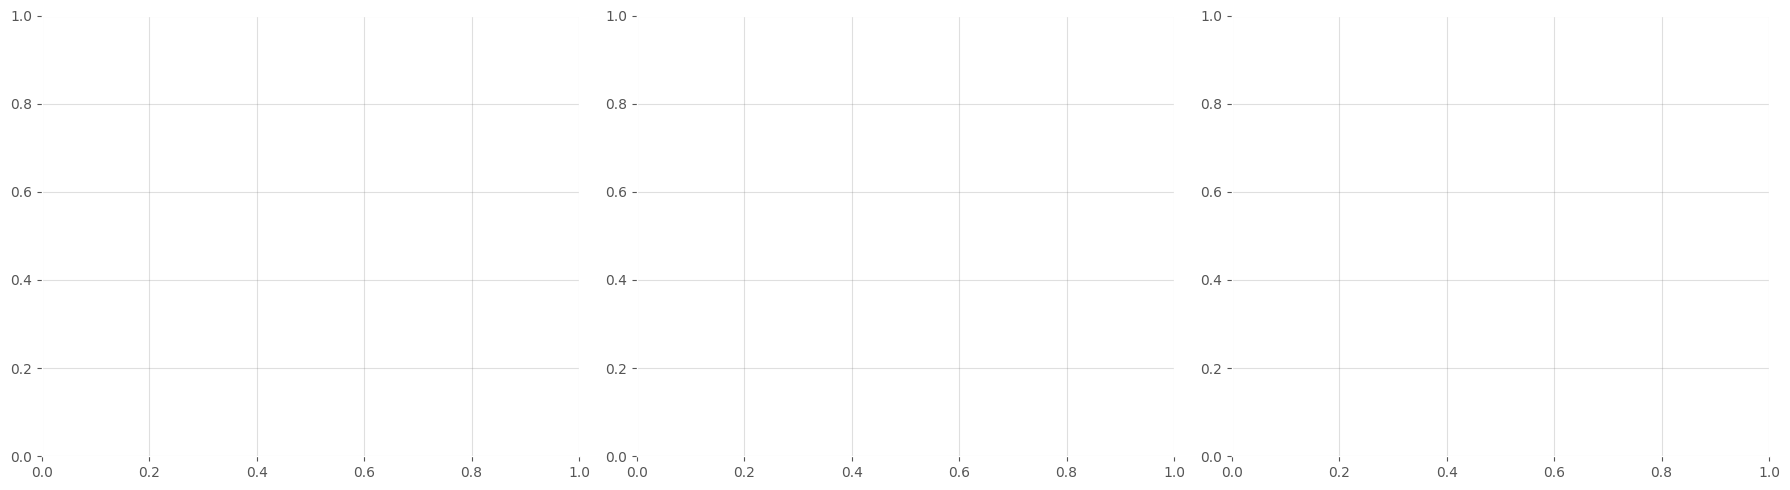

In [96]:
# Visualize t-SNE results
fig, axes = plt.subplots(1, 3, figsize = [18, 5])

# Your code here

plt.tight_layout()
plt.show()

In [97]:
# Compare with PCA 2D

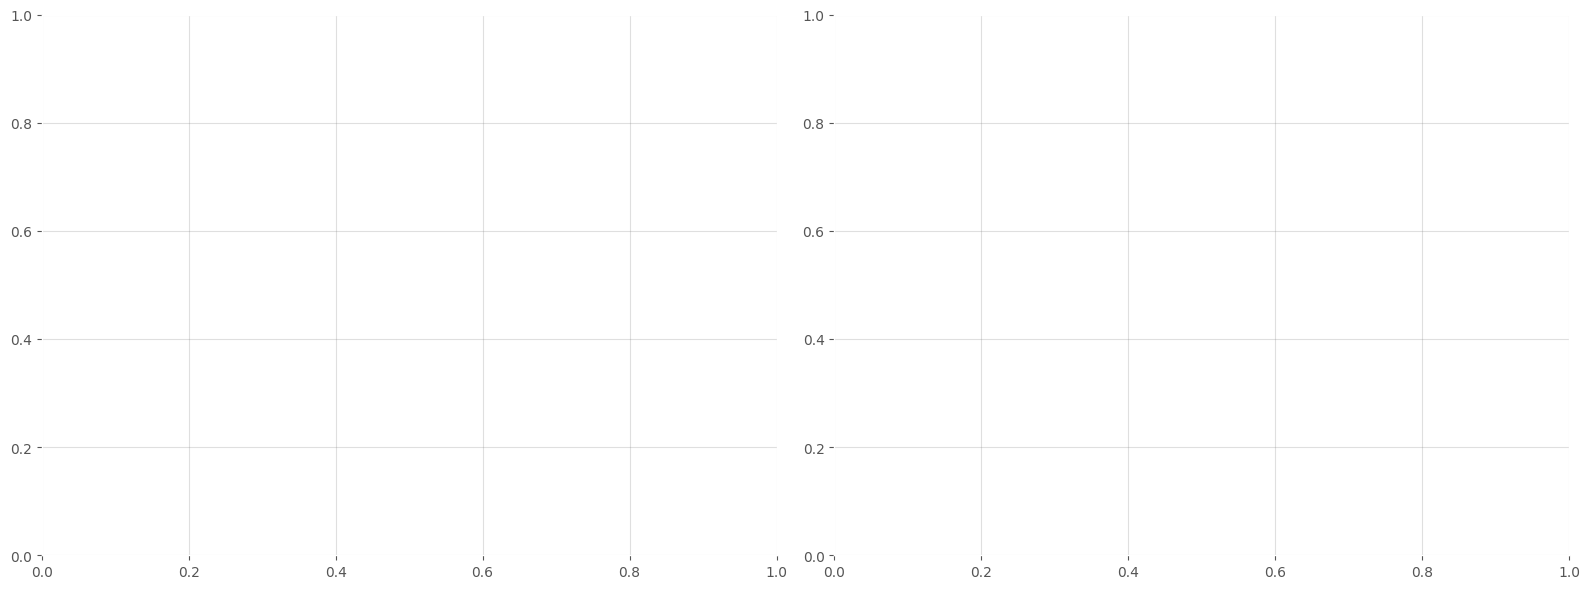

In [98]:
# Combined visualization: PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize = [16, 6])

# Your code here

plt.tight_layout()
plt.show()

### <font color = red> Answer 10 </font>

    Best perplexity for separation: ____________
    
    t-SNE observations:
    - Cluster separation quality: ____________
    - Alignment with K-Means labels: ____________
    
    Comparison: PCA vs t-SNE
    - Better separation: ____________
    - More interpretable: ____________
    - Computational speed: PCA is ____________ than t-SNE
    
    Key insight about sector relationships:
    ____________________________________________________________
    ____________________________________________________________
    
    When to use PCA: ____________________________________________
    
    When to use t-SNE: __________________________________________

***
# BONUS SECTION (15 Extra Points)
***

##  <font color = blue> 👉 Bonus Question 1. </font> Multi-Asset Pairs Trading Strategy (15 points)

### Develop a pairs trading strategy using insights from unsupervised learning.

### Tasks:

a) From your hierarchical clustering analysis (Question 9), select the two most similar ETFs

b) Calculate the price ratio (normalized spread) between the pair

c) Calculate z-score of the spread using 20-day rolling mean and std

d) Generate trading signals:
   - **Enter long spread** (buy undervalued, sell overvalued): z-score < -2
   - **Enter short spread** (sell overvalued, buy undervalued): z-score > 2
   - **Exit positions**: z-score crosses 0

e) Backtest the strategy:
   - Initial capital: $100,000
   - Trade size: $50,000 per leg
   - Calculate P&L

f) Calculate strategy metrics:
   - Total return
   - Sharpe ratio
   - Maximum drawdown
   - Number of round-trip trades

g) Visualize:
   - Normalized prices of both ETFs
   - Z-score with entry/exit signals
   - Cumulative P&L

h) Provide a brief critique: Is this a viable trading strategy?

### Below are the lines of code that lead to an answer:

In [99]:
# Your bonus question code here

In [100]:
# Pairs trading strategy implementation

In [101]:
# Backtesting

In [102]:
# Visualization

### <font color = red> Bonus Answer </font>

    Selected pair: ____________ and ____________
    
    Strategy Performance:
    - Total Return: ____________%
    - Sharpe Ratio: ____________
    - Maximum Drawdown: ____________%
    - Number of trades: ____________
    - Win rate: ____________%
    
    Critique:
    ____________________________________________________________
    ____________________________________________________________
    ____________________________________________________________
    
    Suggested improvements:
    ____________________________________________________________
    ____________________________________________________________

***
# SUBMISSION CHECKLIST
***

### Before submitting, ensure:

- [ ] All import statements are executed
- [ ] All code cells run without errors
- [ ] All answer cells are completed
- [ ] All visualizations display correctly
- [ ] Functions are defined within the notebook
- [ ] The workspace has been displayed using `%whos`
- [ ] File saved as: `YourLastName_MockExam2.ipynb`

### Execute the cell below to show your workspace:

In [104]:
%who_ls

['AgglomerativeClustering',
 'Axes3D',
 'DecisionTreeRegressor',
 'ElasticNet',
 'GGBunch',
 'GradientBoostingRegressor',
 'KMeans',
 'KNeighborsRegressor',
 'Lasso',
 'LetsPlot',
 'LinearRegression',
 'NumComponents',
 'NumEigenValues',
 'PCA',
 'PCWeights',
 'PrincipalComponent',
 'RANDOM_SEED',
 'RandomForestRegressor',
 'Ridge',
 'StandardScaler',
 'TSNE',
 'X',
 'X_test',
 'X_test_scaled',
 'X_train',
 'X_train_scaled',
 'Z',
 'adjusted_rand_score',
 'aes',
 'ann_rets',
 'ann_vols',
 'arrow',
 'as_discrete',
 'ax',
 'axes',
 'c',
 'centroids',
 'chosen_clusters',
 'clust_labels1',
 'cluster',
 'cluster_df',
 'cluster_id',
 'clusters',
 'coord_cartesian',
 'coord_fixed',
 'coord_flip',
 'coord_map',
 'coord_polar',
 'data',
 'dendrogram',
 'df',
 'df_boll',
 'df_corr',
 'df_fwd_rets',
 'df_lst',
 'df_rets',
 'df_rsi',
 'df_sma',
 'df_vol',
 'directional_accuracy',
 'distance_threshold',
 'download_csv_data',
 'eigen_portfolios',
 'element_blank',
 'element_geom',
 'element_line',
 

In [103]:
%whos

Variable                     Type                         Data/Info
-------------------------------------------------------------------
AgglomerativeClustering      type                         <class 'sklearn.cluster._<...>AgglomerativeClustering'>
Axes3D                       type                         <class 'mpl_toolkits.mplot3d.axes3d.Axes3D'>
DecisionTreeRegressor        ABCMeta                      <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
ElasticNet                   ABCMeta                      <class 'sklearn.linear_mo<...>nate_descent.ElasticNet'>
GGBunch                      type                         <class 'lets_plot.plot.plot.GGBunch'>
GradientBoostingRegressor    ABCMeta                      

TypeError: object of type 'ABCMeta' has no len()

### <font color = green> 💯 Excellent work completing Mock Assessment Paper 2! 

### You've practiced:

✅ **Data Wrangling**: Multi-source data handling and correlation analysis

✅ **Rule-Based Strategies**: RSI mean-reversion and triple MA momentum

✅ **Performance Analytics**: Comprehensive risk-adjusted metrics

✅ **Supervised Learning**: 8 ML models with feature engineering

✅ **Unsupervised Learning**:
- PCA on sector ETFs with 3D visualization
- K-Means clustering for portfolio construction
- Hierarchical clustering with multiple linkage methods
- t-SNE with parameter sensitivity analysis

✅ **Integration**: Pairs trading combining clustering + signals

***

### Keep practicing and good luck with your exam! 🎯🚀

***